In [1]:
import os
import pandas as pd
import pygmt
import matplotlib.colors as mcolors 
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, ListedColormap
import seaborn as sns
import numpy as np
from scipy.stats import linregress
from scipy import stats


In [2]:
geo_wa=pd.read_csv('./geological_map/waor_station_geology.csv')
geo_wa.head(5)

,netst,stlo,stla,geometry,index_right,STATE,ORIG_LABEL,SGMC_LABEL,UNIT_LINK,UNIT_NAME,...,INDETERMIN,REF_ID,REFERENCE,GENERALIZE,DIGITAL_UR,NGMDB1,NGMDB2,NGMDB3,RuleID,FIPS_C
0,CC.ASBU,-121.368401,43.820560,POINT (-121.368401 43.82056),9310.0,OR,Qyb,Qyb;0,ORQyb;0,Youngest basalt and basaltic andesite,...,NaN,OR392,"Miller, R.J., Raines, G.L., and Connors, K.A.,...","Igneous, volcanic",https://pubs.usgs.gov/of/2003/of03-067/,https://ngmdb.usgs.gov/Prodesc/proddesc_16259.htm,NaN,NaN,2.0,41.0
1,CC.BRSP,-121.708427,45.401550,POINT (-121.708427 45.40155),5175.0,OR,Qa,Qa;0,ORQa;0,Andesite,...,NaN,OR392,"Miller, R.J., Raines, G.L., and Connors, K.A.,...","Igneous, volcanic",https://pubs.usgs.gov/of/2003/of03-067/,https://ngmdb.usgs.gov/Prodesc/proddesc_16259.htm,NaN,NaN,2.0,41.0
2,CC.CARB,-122.005409,46.988319,POINT (-122.005409 46.988319),310.0,WA,E2,EO2;0,WAEO2;0,Lower upper Eocene marine and nonmarine rocks,...,NaN,WA097,"Raines, Gary L., and Johnson, Bruce R., 1996, ...","Sedimentary, clastic",https://pubs.usgs.gov/of/1995/of95-684/,https://ngmdb.usgs.gov/Prodesc/proddesc_30777.htm,NaN,NaN,23.0,53.0
3,CC.CIHL,-121.148621,43.750969,POINT (-121.148621 43.750969),5796.0,OR,Qb,Qb;0,ORQb;0,Basalt and basaltic andesite,...,NaN,OR392,"Miller, R.J., Raines, G.L., and Connors, K.A.,...","Igneous, volcanic",https://pubs.usgs.gov/of/2003/of03-067/,https://ngmdb.usgs.gov/Prodesc/proddesc_16259.htm,NaN,NaN,2.0,41.0
4,CC.CLBH,-122.143494,42.907745,POINT (-122.143494 42.907745),5168.0,OR,Qa,Qa;0,ORQa;0,Andesite,...,NaN,OR392,"Miller, R.J., Raines, G.L., and Connors, K.A.,...","Igneous, volcanic",https://pubs.usgs.gov/of/2003/of03-067/,https://ngmdb.usgs.gov/Prodesc/proddesc_16259.htm,NaN,NaN,2.0,41.0


In [3]:
geo_ca=pd.read_csv('./geological_map/ca_station_geology.csv')
geo_ca.head(5)

,netst,stla,stlo,geometry,index_right,STATE,ORIG_LABEL,SGMC_LABEL,UNIT_LINK,UNIT_NAME,...,INDETERMIN,REF_ID,REFERENCE,GENERALIZE,DIGITAL_UR,NGMDB1,NGMDB2,NGMDB3,RuleID,FIPS_C
0,CI.ALP,34.687080,-118.299461,POINT (-118.299461 34.68708),4810,CA,Q,Q;0,CAQ;0,Quaternary alluvium and marine deposits,...,NaN,CA294,"Jennings, C.W., with modifications by Gutierre...","Unconsolidated, undifferentiated",ftp://ftp.consrv.ca.gov/pub/dmg/rgmp/Published...,https://ngmdb.usgs.gov/Prodesc/proddesc_96750.htm,NaN,NaN,29,6
1,CI.ARV,35.126900,-118.830093,POINT (-118.830093 35.1269),2786,CA,M,MI;0,CAMI;0,Miocene marine rocks,...,NaN,CA294,"Jennings, C.W., with modifications by Gutierre...","Sedimentary, clastic",ftp://ftp.consrv.ca.gov/pub/dmg/rgmp/Published...,https://ngmdb.usgs.gov/Prodesc/proddesc_96750.htm,NaN,NaN,23,6
2,CI.BAI,34.776951,-118.773354,POINT (-118.773354 34.776951),2829,CA,M,MI;0,CAMI;0,Miocene marine rocks,...,NaN,CA294,"Jennings, C.W., with modifications by Gutierre...","Sedimentary, clastic",ftp://ftp.consrv.ca.gov/pub/dmg/rgmp/Published...,https://ngmdb.usgs.gov/Prodesc/proddesc_96750.htm,NaN,NaN,23,6
3,CI.BAK,35.344440,-119.104446,POINT (-119.104446 35.34444),4830,CA,Q,Q;0,CAQ;0,Quaternary alluvium and marine deposits,...,NaN,CA294,"Jennings, C.W., with modifications by Gutierre...","Unconsolidated, undifferentiated",ftp://ftp.consrv.ca.gov/pub/dmg/rgmp/Published...,https://ngmdb.usgs.gov/Prodesc/proddesc_96750.htm,NaN,NaN,29,6
4,CI.BBR,34.262299,-116.920753,POINT (-116.920753 34.262299),4848,CA,Q,Q;0,CAQ;0,Quaternary alluvium and marine deposits,...,NaN,CA294,"Jennings, C.W., with modifications by Gutierre...","Unconsolidated, undifferentiated",ftp://ftp.consrv.ca.gov/pub/dmg/rgmp/Published...,https://ngmdb.usgs.gov/Prodesc/proddesc_96750.htm,NaN,NaN,29,6


In [4]:
geo_in=pd.concat([geo_wa,geo_ca])

In [5]:
geo_df=geo_in[['netst',
               'stlo',
               'stla',
               'STATE',
               'GENERALIZE',
               'MAJOR1']]

In [6]:
geo_df.dropna(subset=['GENERALIZE'],inplace=True)

/tmp/ipykernel_3533631/2092695932.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geo_df.dropna(subset=['GENERALIZE'],inplace=True)


In [7]:
rock_types=geo_df['GENERALIZE'].unique()
rock_types

array(['Igneous, volcanic', 'Sedimentary, clastic',
       'Unconsolidated, undifferentiated', 'Igneous, undifferentiated',
       'Igneous, intrusive',
       'Metamorphic and Sedimentary, undifferentiated',
       'Metamorphic, sedimentary', 'Water',
       'Igneous and Sedimentary, undifferentiated',
       'Metamorphic, serpentinite', 'Metamorphic, schist',
       'Metamorphic, sedimentary clastic',
       'Unconsolidated and Sedimentary, undifferentiated',
       'Sedimentary, carbonate', 'Metamorphic, volcanic',
       'Metamorphic, gneiss', 'Igneous and Metamorphic, undifferentiated',
       'Sedimentary, undifferentiated'], dtype=object)

In [8]:
geo_df2 = geo_df.dropna(subset=['stlo', 'stla', 'GENERALIZE'])

geo_colors = {
    # **Unconsolidated Rocks** (Yellow to orange gradient)
    'Unconsolidated, undifferentiated': '#FFEB3B',   # Bright yellow (light yellow)
    'Unconsolidated and Sedimentary, undifferentiated': '#FF9800',  # Orange (for undifferentiated sediments)

    # **Sedimentary Rocks** (Yellow-based to orange and brown tones)
    'Sedimentary, clastic': '#FFB300',               # Amber yellow (clastic sedimentary)
    'Sedimentary, carbonate': '#FBC02D',             # Golden yellow (carbonate sedimentary)
    'Sedimentary, undifferentiated': '#F57C00',      # Burnt orange (undifferentiated sedimentary)

    # **Igneous Rocks** (Red-based for volcanic and purple-based for intrusive)
    'Igneous, volcanic': '#D32F2F',                  # Deep red (for volcanic)
    'Igneous, intrusive': '#9C27B0',                 # Purple-based (for intrusive igneous)
    'Igneous, undifferentiated': '#E57373',          # Light red (undifferentiated igneous)
    'Igneous and Sedimentary, undifferentiated': '#F06292', # Pinkish red (mixed igneous and sedimentary)

    # **Metamorphic Rocks** (Green-based with variations)
    'Metamorphic, sedimentary': '#66BB6A',           # Light green (for sedimentary metamorphics)
    'Metamorphic, schist': '#2E7D32',                # Deep green (for schist)
    'Metamorphic, serpentinite': '#81C784',          # Soft green (for serpentinite)
    'Metamorphic, volcanic': '#388E3C',              # Forest green (for volcanic metamorphics)
    'Metamorphic, gneiss': '#1B5E20',                # Dark green (for gneiss)
    'Metamorphic and Sedimentary, undifferentiated': '#43A047', # Medium green (undifferentiated metamorphics)
    'Metamorphic, sedimentary clastic': '#4CAF50',   # Fresh green (for clastic metamorphics)
    'Igneous and Metamorphic, undifferentiated': '#8E24AA', # Violet-green mix (for igneous/metamorphic undifferentiated)

    # **Water** (Clear and bright blue)
    'Water': '#80D8FF',                              # Soft turquoise-blue (for water)

    # **NaN or Missing Data** (Neutral gray)
    None: '#BDBDBD',                                 # Light gray for undefined or NaN entries
    # 'nan': '#BDBDBD'                                 # Handling 'nan' as a string explicitly if needed
}



# Map geological units to colors
geo_df2['color'] = geo_df2['GENERALIZE'].map(geo_colors).fillna('#d3d3d3') 


coast [WARNING]: 0/0.1 not a valid number and may not be decoded properly.


Unconsolidated, undifferentiated #FFEB3B
Unconsolidated and Sedimentary, undifferentiated #FF9800
Sedimentary, clastic #FFB300
Sedimentary, carbonate #FBC02D
Sedimentary, undifferentiated #F57C00
Igneous, volcanic #D32F2F
Igneous, intrusive #9C27B0
Igneous, undifferentiated #E57373
Igneous and Sedimentary, undifferentiated #F06292
Metamorphic, sedimentary #66BB6A
Metamorphic, schist #2E7D32
Metamorphic, serpentinite #81C784
Metamorphic, volcanic #388E3C
Metamorphic, gneiss #1B5E20
Metamorphic and Sedimentary, undifferentiated #43A047
Metamorphic, sedimentary clastic #4CAF50
Igneous and Metamorphic, undifferentiated #8E24AA
Water #80D8FF
None #BDBDBD


coast [WARNING]: 0/0.1 not a valid number and may not be decoded properly.


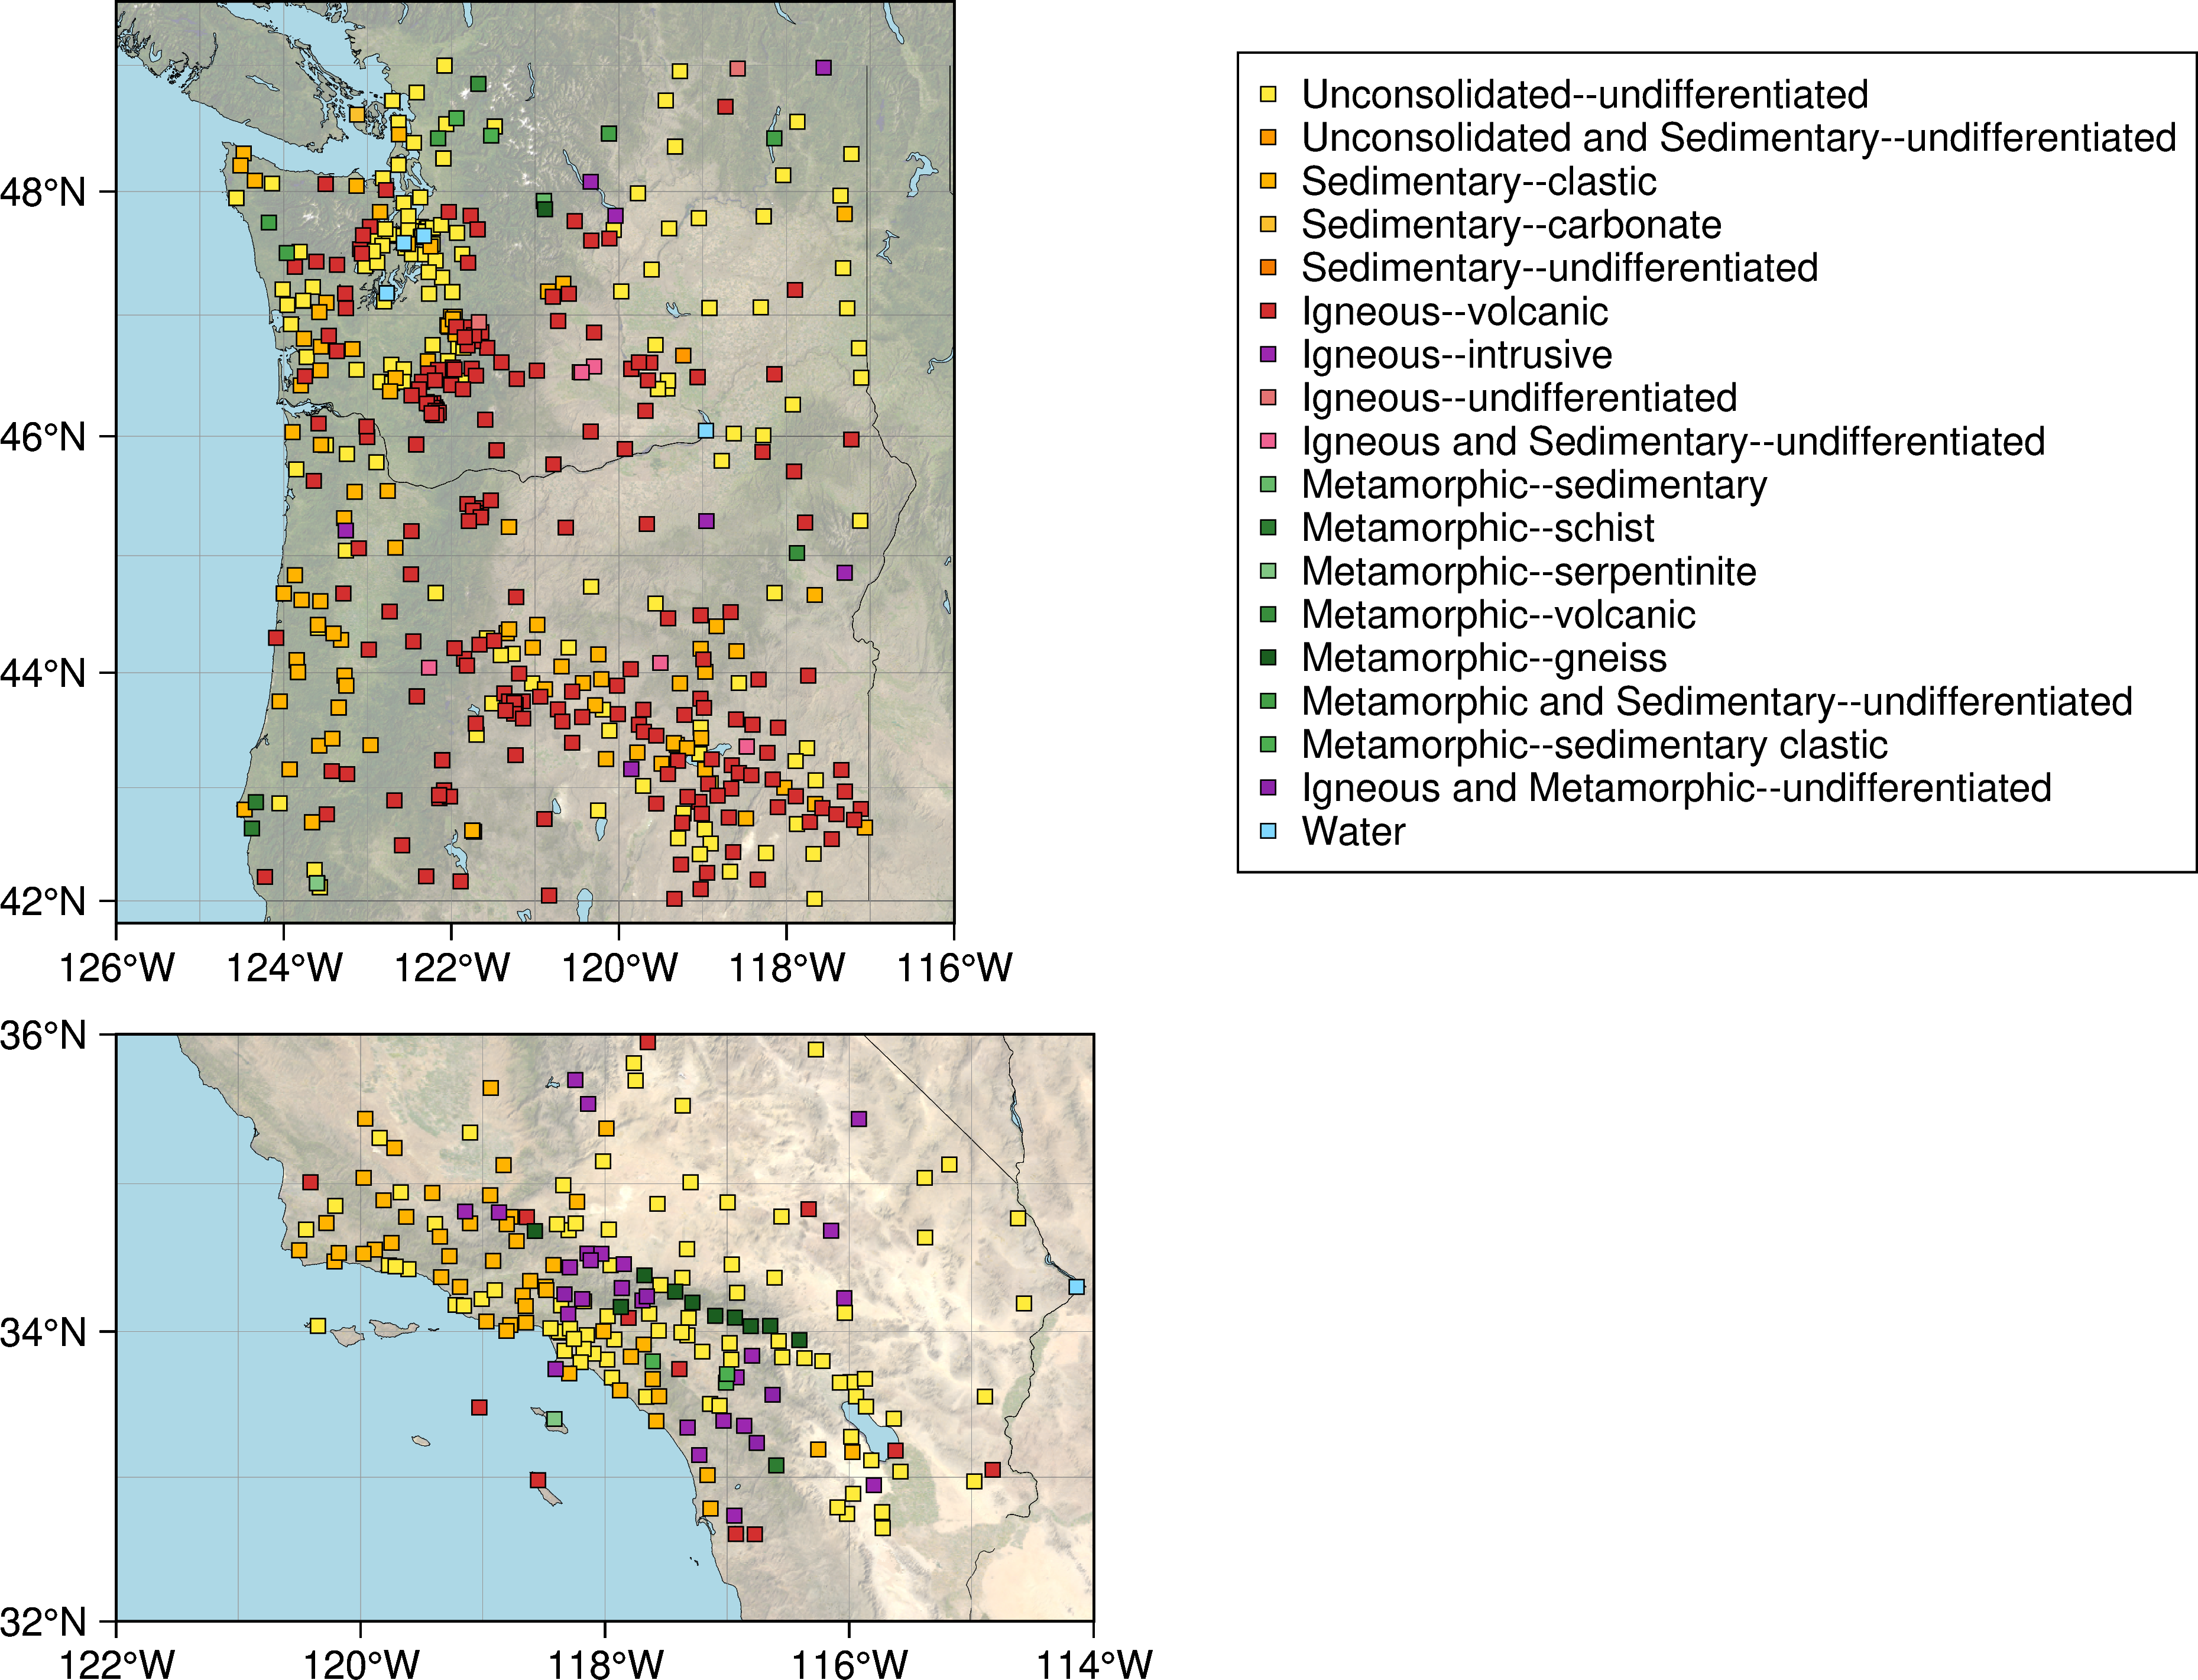

In [9]:
# PyGMT Plot
fig = pygmt.Figure()
region=[-126,-116,41.8,49.5]
proj='M6c'

pygmt.config(MAP_GRID_PEN = '0.01p,150' , MAP_FRAME_PEN='0.5p', MAP_FRAME_TYPE="plain", MAP_TITLE_OFFSET="0.12p", FONT_TITLE="12p", FONT_ANNOT='8p',  )
 
# Plot the basemap
fig.basemap(region=region,  projection=proj, frame="a2g1", )
grid = pygmt.datasets.load_earth_relief(resolution="30s", region=region)
fig.grdimage(grid='@earth_day_30s', projection=proj, transparency=60, )
fig.coast(region=region, projection=proj, frame="a2g1", resolution="f", borders="2/0.05p",
            water='lightblue', shorelines='0/0.1p',)

# Plot each geological unit as colored circles
for unit, color in geo_colors.items():
    print(unit, color)
    geo_plot = geo_df2[geo_df2['color'] == color]
    formatted_label = str(unit).replace(", ", "--")
    if not geo_plot.empty:
        fig.plot(
                x=geo_plot['stlo'],
                y=geo_plot['stla'],
                style="s0.15c",  
                fill=color,
                pen="black",
                label=f'{formatted_label}'
        )

fig.legend(position="JMR+o0.8i/0i", box="+gwhite+p0.4p")
# fig.shift_origin(xshift="7c")
fig.shift_origin(yshift="-5c")
proj='M7c'
region=[-122,-114,32,36]
pygmt.config(MAP_GRID_PEN = '0.01p,150' , MAP_FRAME_PEN='0.5p', MAP_FRAME_TYPE="plain", MAP_TITLE_OFFSET="0.12p", FONT_TITLE="12p", FONT_ANNOT='8p',  )
 
# Plot the basemap
fig.basemap(region=region,  projection=proj, frame="a2g1", )
grid = pygmt.datasets.load_earth_relief(resolution="30s", region=region)
fig.grdimage(grid='@earth_day_30s', projection=proj, transparency=60, )

fig.coast(region=region, projection=proj, frame="a2g1", resolution="f", borders="2/0.05p",
            water='lightblue', shorelines='0/0.1p',)
# Plot each geological unit as colored circles
for unit, color in geo_colors.items():
    # print(unit, color)
    geo_plot = geo_df2[geo_df2['color'] == color]
    formatted_label = str(unit).replace(", ", "--")
    if not geo_plot.empty:
        fig.plot(
            x=geo_plot["stlo"],
            y=geo_plot["stla"],
            style="s0.15c",
            fill=color,
            pen="black",
            label=f"{formatted_label}",  # Use formatted label
        )


fig.show(dpi=600)



In [10]:
print(geo_df.MAJOR1.unique())

['Basaltic-andesite' 'Siltstone' 'Basalt' 'Rhyolite' 'Sandstone' 'Clay'
 'Silt' 'Andesite' 'Sand' 'Fine-detrital' 'Quartz-monzonite' 'Granite'
 'Graywacke' 'Gravel' 'Metasedimentary' nan 'Arkose' 'Mudstone' 'Gabbro'
 'Sandstone-mudstone' 'Quartz-diorite' 'Coarse-detrital' 'Mixed-clastic'
 'Serpentinite' 'Pelitic-schist' 'Volcanic' 'Phyllite' 'Conglomerate'
 'Limestone' 'Greenstone' 'Gneiss' 'Metaandesite' 'Hypabyssal-basalt'
 'Plutonic' 'Orthogneiss' 'Shale' 'Anorthosite' 'Tonalite' 'Argillite'
 'Felsic-volcanic' 'Granodiorite' 'Diorite' 'Hypabyssal-rhyolite' 'Dacite']


In [11]:
geo_major = geo_df.dropna(subset=['stlo', 'stla', 'MAJOR1'])

# Define color dictionary for geological units
major_colors = {
    # **Sedimentary Rocks** (Yellow-based gradient, yellow to orange)
    'Siltstone': '#FFEB3B',              # Bright yellow
    'Sandstone': '#FFB300',              # Darker yellow-orange
    'Clay': '#FF6F00',                  # Deep amber-orange
    'Silt': '#FFF176',                  # Pale yellow (lighter)
    'Fine-detrital': '#FF9800',          # Strong orange
    'Graywacke': '#FF5722',             # Orange-red
    'Arkose': '#F57C00',                # Intense amber-orange
    'Mudstone': '#E65100',              # Dark amber-orange
    'Conglomerate': '#D32F2F',          # Red-orange
    'Limestone': '#FF7043',             # Peachy-orange
    'Sandstone-mudstone': '#FF5722',    # Reddish-orange
    'Mixed-clastic': '#E64A19',         # Orange-red
    'Coarse-detrital': '#BF360C',       # Dark orange-red
    'Shale': '#F9A825',                 # Amber-yellow with slight orange
    'Gravel': '#B59A5B',                # Beige with brown undertones
    'Argillite': '#FF6F00',             # Amber-orange
    'Sand': '#FFB300',                 # Darker yellow-orange

    # **Volcanic Rocks** (Purple-based gradient, dark purple to lavender)
    'Basaltic-andesite': '#512DA8',     # Dark purple
    'Basalt': '#3F51B5',                # Dark bluish purple
    'Rhyolite': '#5E35B1',              # Medium dark purple
    'Andesite': '#7E57C2',              # Medium purple
    'Granite': '#9C27B0',               # Vibrant purple
    'Volcanic': '#8E24AA',              # Purple-pink
    'Metaandesite': '#9C27B0',          # Rich purple
    'Hypabyssal-basalt': '#7B1FA2',     # Deep purple with pinkish tint
    'Hypabyssal-rhyolite': '#AB47BC',   # Lavender purple
    'Dacite': '#512DA8',                # Dark purple, same as basaltic-andesite
    'Granodiorite': '#4CAF50',          # Purple with brownish tones

    # **Metamorphic Rocks** (Green-based gradient)
    'Metasedimentary': '#66BB6A',       # Light green
    'Pelitic-schist': '#4CAF50',         # Medium green
    'Serpentinite': '#2E7D32',           # Dark green
    'Phyllite': '#388E3C',              # Medium dark green
    'Gneiss': '#2C6B31',                # Deep green
    'Schist': '#1B5E20',                # Dark green
    'Mica-schist': '#388E3C',           # Rich green
    'Slate': '#43A047',                 # Bright green
    'Metamorphic': '#1B5E20',           # Dark forest green
    'Amphibolite': '#2E7D32',           # Deep green with slight yellow
    'Orthogneiss': '#66BB6A',           # Soft green, slightly grayish

    # **Other Rock Types**
    'Water': '#80D8FF',                # Soft turquoise-blue
    'Greenstone': '#A8D58B',           # Soft mint green
    'Plutonic': '#388E3C',             # Greenish stone-like, similar to Metamorphic
    'Anorthosite': '#80D8FF',          # Turquoise-greenish
    'Tonalite': '#9C27B0',             # Purple hue with slight bluish tinge
    'Quartz-monzonite': '#9C27B0',     # Vibrant purple, same as granite
    'Gabbro': '#3F51B5',               # Bluish dark green
    'Quartz-diorite': '#512DA8',       # Dark purple with grayish tones
    'Diorite': '#7E57C2',              # Medium purple
    'Felsic-volcanic': '#9C27B0',      # Bright vibrant purple, similar to granite
}



# Map geological units to colors
geo_major['color'] = geo_major['MAJOR1'].map(major_colors).fillna('#d3d3d3') 


/tmp/ipykernel_3533631/1836539442.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geo_major['color'] = geo_major['MAJOR1'].map(major_colors).fillna('#d3d3d3')


coast [WARNING]: 0/0.1 not a valid number and may not be decoded properly.
coast [WARNING]: 0/0.1 not a valid number and may not be decoded properly.


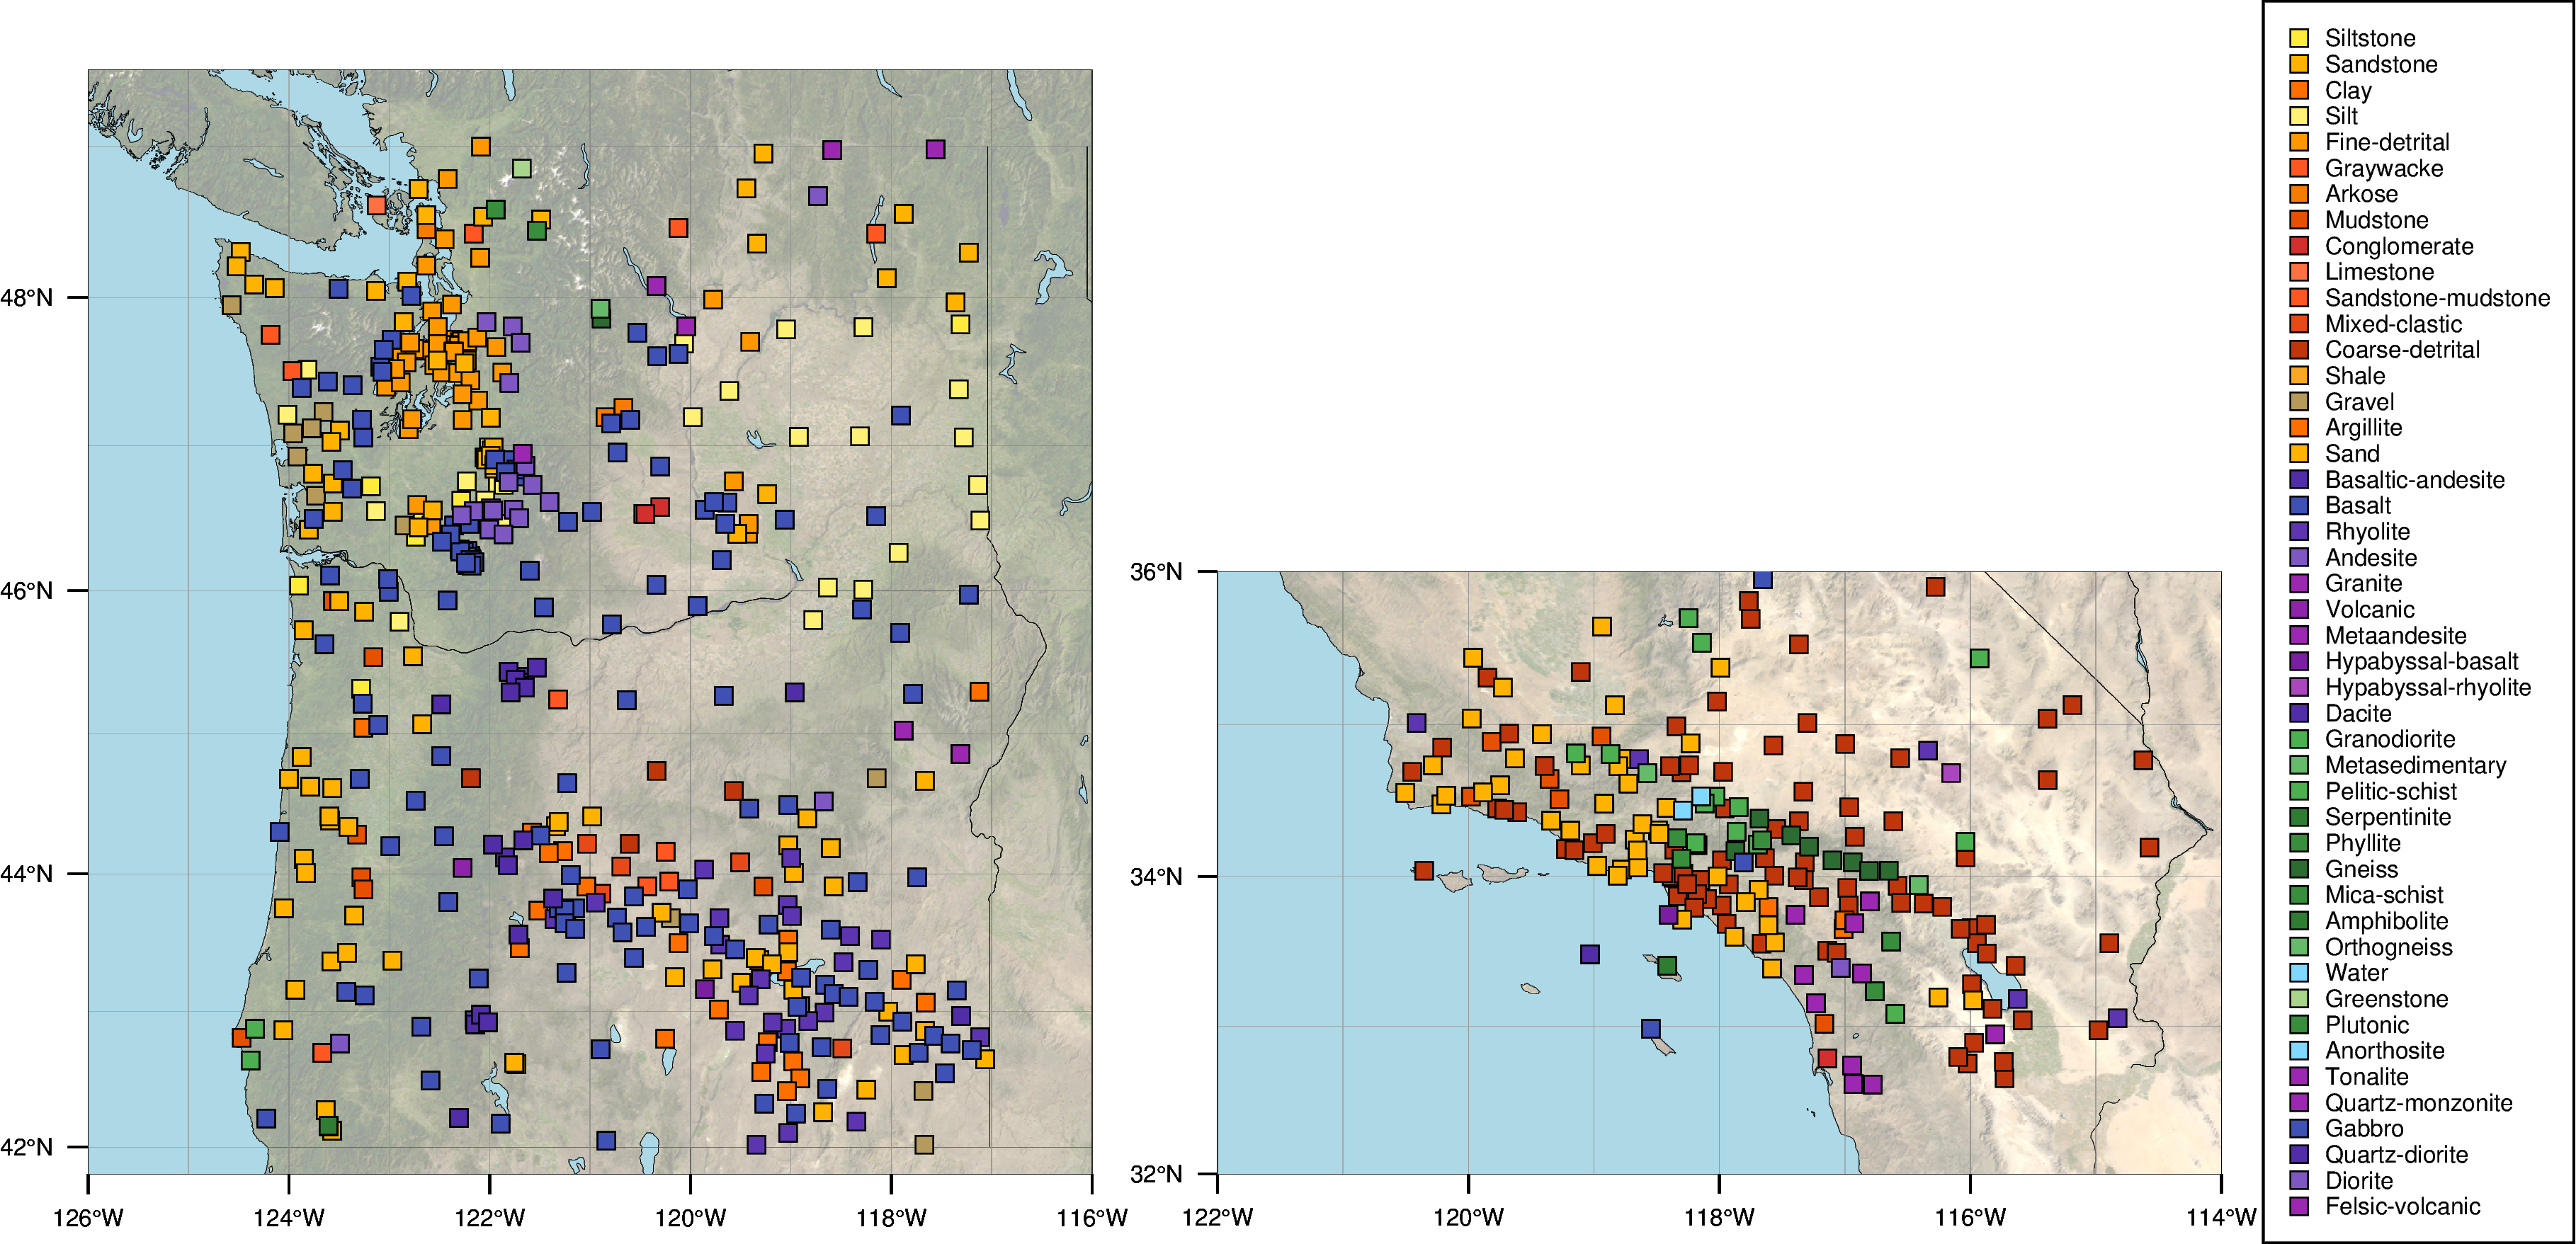

In [12]:
# Load CSV data
df = geo_major
region=[-126,-116,41.8,49.5]
proj='M6c'
# Initialize the figure
fig = pygmt.Figure()
pygmt.config(MAP_GRID_PEN = '0.01p,150' , MAP_FRAME_PEN='0.05p', MAP_FRAME_TYPE="plain", MAP_TITLE_OFFSET="0.12p", FONT_TITLE="12p", FONT_ANNOT='4p',  )
 
# Plot the basemap
fig.basemap(region=region,  projection=proj, frame="a2g1", )
grid = pygmt.datasets.load_earth_relief(resolution="30s", region=region)
fig.grdimage(grid='@earth_day_30s', projection=proj, transparency=60, )

fig.coast(region=region, projection=proj, frame="a2g1", resolution="f", borders="2/0.05p",
            water='lightblue', shorelines='0/0.1p',)
            
# Plot each geological unit as colored circles
for unit, color in major_colors.items():
    geo_plot = geo_major[geo_major['color'] == color]
    if not geo_plot.empty:
        fig.plot(
                x=geo_plot['stlo'],
                y=geo_plot['stla'],
                style="s0.15c",  
                fill=color,
                pen="black",
                label=unit
                )
fig.shift_origin(xshift="7c")
fig.legend(position="JMR", box="+gwhite+p0.4p",)
fig.shift_origin(xshift="-0.25c")

region=[-122,-114,32,36]
pygmt.config(MAP_GRID_PEN = '0.01p,150' , MAP_FRAME_PEN='0.05p', MAP_FRAME_TYPE="plain", MAP_TITLE_OFFSET="0.12p", FONT_TITLE="12p", FONT_ANNOT='4p',  )
 
# Plot the basemap
fig.basemap(region=region,  projection=proj, frame="a2g1", )
grid = pygmt.datasets.load_earth_relief(resolution="30s", region=region)
fig.grdimage(grid='@earth_day_30s', projection=proj, transparency=60, )

fig.coast(region=region, projection=proj, frame="a2g1", resolution="f", borders="2/0.05p",
            water='lightblue', shorelines='0/0.1p',)
# Plot each geological unit as colored circles
for unit, color in major_colors.items():
    geo_plot = geo_major[geo_major['color'] == color]
    formatted_label = str(unit).replace(", ", "--")
    if not geo_plot.empty:
        fig.plot(
            x=geo_plot["stlo"],
            y=geo_plot["stla"],
            style="s0.15c",
            fill=color,
            pen="black",
            label=f"{formatted_label}",  # Use formatted label
        )


fig.show(dpi=600)

In [13]:
pd_pnwbb=pd.read_csv('attenuation_PNW/sta_waro_vs30.csv')
pd_cabb=pd.read_csv('attenuation_SouthCA/sta_CI_vs30.csv')
pd_comb=pd.concat([pd_pnwbb,pd_cabb])

In [14]:
# Merging pd1 with pd2 on the 'netst' column
merged_geo = pd_comb.merge(geo_df, on='netst', how='left')
merged_geo = merged_geo[merged_geo.meanb > 0.01]

# Display the merged DataFrame
merged_geo.to_csv('merged_geo.csv', index=False)

In [15]:
merged_geo.head(5)

,Unnamed: 0,fband,netst,stlo_x,stla_x,meanb,meanQ,ncount,nearest_lon,nearest_lat,vs30,stlo_y,stla_y,STATE,GENERALIZE,MAJOR1
0,0,0.5-1.0,LI.LTH,-119.417679,46.461700,0.080000,58.905,2,-119.4174,46.4613,266.2870,-119.417679,46.461700,WA,"Unconsolidated, undifferentiated",Fine-detrital
2,2,0.5-1.0,TA.I05A,-121.267502,44.162601,0.316667,14.894,3,-121.2674,44.1633,425.7540,-121.267502,44.162601,OR,"Unconsolidated, undifferentiated",Clay
5,5,0.5-1.0,XN.B05,-125.766998,58.930500,0.050000,94.248,1,-123.0833,49.0012,324.2436,NaN,NaN,NaN,NaN,NaN
6,6,0.5-1.0,XN.B12,-131.744400,59.932999,0.110000,42.840,1,-124.7213,48.3872,605.8344,NaN,NaN,NaN,NaN,NaN
7,7,0.5-1.0,XN.C02,-122.713898,58.096500,0.020000,235.619,1,-122.7133,49.0012,426.8878,NaN,NaN,NaN,NaN,NaN


In [16]:
# Map geological units to colors
merged_geo['color_major'] = merged_geo['MAJOR1'].map(major_colors).fillna('#d3d3d3') 
merged_geo['color_gener'] = merged_geo['GENERALIZE'].map(geo_colors).fillna('#d3d3d3') 


In [17]:
# -122, -121.4, 46.7, 47
MtRainer=merged_geo[(merged_geo.stlo_x >-122) & (merged_geo.stlo_x <-121.4) & (merged_geo.stla_x >46.7) & (merged_geo.stla_x <47)]
# -121.9, -121.4, 45, 45.5
MtHood=merged_geo[(merged_geo.stlo_x >-121.9) & (merged_geo.stlo_x <-121.4) & (merged_geo.stla_x >45) & (merged_geo.stla_x <45.5)]
# -122.4, -121.9, 46, 46.4
MtStHelens=merged_geo[(merged_geo.stlo_x >-122.45) & (merged_geo.stlo_x <-121.9) & (merged_geo.stla_x >46) & (merged_geo.stla_x <46.4)]


In [18]:
print("MtStHelens-----")
for k, freq in enumerate(MtStHelens.fband.unique()):
    pdin=MtStHelens[MtStHelens.fband == freq]
    print((pdin.describe()))
print("MtHood-----")
for k, freq in enumerate(MtHood.fband.unique()):
    pdin=MtHood[MtHood.fband == freq]
    print((pdin.describe()))
print("MtRainer-----")
for k, freq in enumerate(MtRainer.fband.unique()):
    pdin=MtRainer[MtRainer.fband == freq]
    print((pdin.describe()))


MtStHelens-----
       Unnamed: 0      stlo_x     stla_x     meanb       meanQ    ncount  \
count    4.000000    4.000000   4.000000  4.000000    4.000000  4.000000   
mean   162.750000 -122.215569  46.224879  0.209375  118.265125  4.250000   
std     82.588841    0.054114   0.040849  0.083101  196.607344  2.872281   
min     48.000000 -122.296669  46.199780  0.102500   16.250000  1.000000   
25%    145.500000 -122.217310  46.200094  0.166250   17.866625  3.250000   
50%    179.000000 -122.190052  46.207209  0.222500   21.845500  4.000000   
75%    196.250000 -122.188311  46.231994  0.265625  122.244000  5.000000   
max    245.000000 -122.185501  46.285320  0.290000  413.119500  8.000000   

       nearest_lon  nearest_lat        vs30      stlo_y     stla_y  
count     4.000000     4.000000    4.000000    4.000000   4.000000  
mean   -122.215900    46.224300  771.343125 -122.215569  46.224879  
std       0.054391     0.041199  208.306976    0.054114   0.040849  
min    -122.297400    4

In [19]:
# ! pip install pandas geopandas shapely scikit-learn haversine


In [20]:
merged_geo.drop(['stlo_y','stla_y', 'Unnamed: 0'], axis=1, inplace=True)
merged_geo=merged_geo.dropna(subset=["GENERALIZE", "MAJOR1"])
merged_geo

,fband,netst,stlo_x,stla_x,meanb,meanQ,ncount,nearest_lon,nearest_lat,vs30,STATE,GENERALIZE,MAJOR1,color_major,color_gener
0,0.5-1.0,LI.LTH,-119.417679,46.461700,0.080000,58.905000,2,-119.4174,46.4613,266.2870,WA,"Unconsolidated, undifferentiated",Fine-detrital,#FF9800,#FFEB3B
2,0.5-1.0,TA.I05A,-121.267502,44.162601,0.316667,14.894000,3,-121.2674,44.1633,425.7540,OR,"Unconsolidated, undifferentiated",Clay,#FF6F00,#FFEB3B
11,0.5-1.0,UW.ERW,-122.626007,48.453838,0.020000,235.619000,1,-122.6254,48.4532,738.0000,WA,"Sedimentary, clastic",Arkose,#F57C00,#FFB300
12,0.5-1.0,UW.SP2,-122.249229,47.556290,0.036667,307.302667,9,-122.2494,47.5572,331.0745,WA,"Sedimentary, clastic",Sandstone,#FFB300,#FFB300
13,0.5-1.0,TA.A04A,-122.707001,48.719700,0.090000,52.360000,1,-122.7073,48.7192,558.2201,WA,"Unconsolidated, undifferentiated",Sand,#FFB300,#FFEB3B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426,2.0-4.0,CI.WSS,-118.649712,34.171700,0.350000,53.856000,1,-118.6495,34.1716,328.1622,CA,"Sedimentary, clastic",Sandstone,#FFB300,#FFB300
1427,2.0-4.0,CI.WTT2,-118.255386,33.948669,0.180000,104.720000,1,-118.2555,33.9496,266.2565,CA,"Unconsolidated, undifferentiated",Coarse-detrital,#BF360C,#FFEB3B
1428,2.0-4.0,CI.WWC,-116.408760,33.940681,0.330000,57.120000,1,-116.4095,33.9416,690.8995,CA,"Metamorphic, gneiss",Orthogneiss,#66BB6A,#1B5E20
1429,2.0-4.0,CI.XTL2,-117.862488,34.295959,0.470000,40.105000,1,-117.8615,34.2956,826.0000,CA,"Igneous, intrusive",Granodiorite,#4CAF50,#9C27B0


In [21]:
import geopandas as gpd
from shapely.geometry import Point

# 1. Load coastline (110m physical)
url = "https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip"
coastline_gdf = gpd.read_file(url)
coastline_union = coastline_gdf.unary_union

# 2. Distance function
def dist_to_shore(row, coastline_geom):
    if pd.isna(row['stlo_x']) or pd.isna(row['stla_x']):
        return pd.NA
    point = Point(row['stlo_x'], row['stla_x'])
    distance_deg = coastline_geom.distance(point)
    return distance_deg * 111.32   # km

# 3. Apply
merged_geo['dist_to_shore_km'] = merged_geo.apply(lambda r: dist_to_shore(r, coastline_union), axis=1)


/tmp/ipykernel_3533631/3726388134.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  coastline_union = coastline_gdf.unary_union


In [22]:
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import silhouette_score
# import warnings
# import geodatasets
# import requests
# import shutil # For cleanup

# # Suppress warnings for cleaner output and plotting
# warnings.filterwarnings('ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=UserWarning)

# # 1. Load your existing DataFrame (Using the sample data)
# df = merged_geo.copy()

# # 2. Function to robustly get the world map shapefile
# def get_world_map_gdf():
#     try:
#         # Try geodatasets first
#         path = geodatasets.get_path("naturalearth_lowres")
#         return gpd.read_file(path)
#     except Exception:
#         print("geodatasets failed to load 'naturalearth_lowres'. Attempting manual download fallback.")
#         # Manual download fallback
#         url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
#         download_dir = './ne_world_map'
#         zip_path = f'{download_dir}/ne_110m_admin_0_countries.zip'
#         shape_path = f'{download_dir}/ne_110m_admin_0_countries.shp'

#         if not os.path.exists(shape_path):
#             os.makedirs(download_dir, exist_ok=True)
#             try:
#                 r = requests.get(url, allow_redirects=True)
#                 with open(zip_path, 'wb') as f:
#                     f.write(r.content)
#                 with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#                     zip_ref.extractall(download_dir)
#                 print("Manual download successful.")
#             except Exception as e:
#                 print(f"Manual download failed: {e}")
#                 return None
        
#         return gpd.read_file(shape_path)

# # Function to find optimal K using the Silhouette Score (as before)
# def find_optimal_k_silhouette(X_scaled, max_k=5):
#     if len(X_scaled) <= max_k: return 2
#     best_k, best_score = 2, -1
#     for i in range(2, max_k + 1):
#         kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
#         cluster_labels = kmeans.fit_predict(X_scaled)
#         score = silhouette_score(X_scaled, cluster_labels)
#         if score > best_score:
#             best_score = score
#             best_k = i
#     return best_k

# # 4. Analyze each fband separately, cluster, and plot (side-by-side)

# unique_fbands = df['fband'].unique()
# numerical_features = ['meanQ', 'vs30', 'dist_to_shore_km']
# categorical_features = ['GENERALIZE', 'MAJOR1']

# for band in unique_fbands:
#     df_band = df[df['fband'] == band].copy()
#     df_band_encoded = pd.get_dummies(df_band, columns=categorical_features, dummy_na=True)
    
#     X_band_features = [col for col in df_band_encoded.columns if col in numerical_features or any(col.startswith(cat) for cat in categorical_features)]
#     df_band_cleaned = df_band_encoded.dropna(subset=['meanQ', 'vs30', 'stlo_x', 'stla_x'])
#     X_band_features = [f for f in X_band_features if f in df_band_cleaned.columns and df_band_cleaned[f].notna().any()]

#     if len(df_band_cleaned) < 3:
#         print(f"Not enough data points ({len(df_band_cleaned)}) in band {band} for clustering. Skipping.\n")
#         continue

#     X_band = df_band_cleaned[X_band_features]
#     scaler = StandardScaler()
#     X_band_scaled = scaler.fit_transform(X_band)

#     k = find_optimal_k_silhouette(X_band_scaled, max_k=min(len(X_band_scaled) - 1, 5)) 
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     df_band_cleaned.loc[:, 'cluster_label'] = kmeans.fit_predict(X_band_scaled)
    
#     # --- Plotting Side-by-Side ---
    
#     fig, axes = plt.subplots(1, 3, figsize=(21, 8)) # 1 row, 2 columns

#     # Plot 1: Q vs Vs30 scatter plot (Left Axis)
#     axes[0].scatter(df_band_cleaned['vs30'], df_band_cleaned['meanQ'], c=df_band_cleaned['cluster_label'], cmap='Set1', s=60, alpha=0.8)
#     axes[0].set_title(f'Q vs Vs30 for fband {band} Hz (K={k})')
#     axes[0].set_xlabel('Vs30 (m/s)')
#     axes[0].set_ylabel('Mean Attenuation (Q)')
#     axes[0].grid(True)
    
#     world = get_world_map_gdf()
#     # Plot 2: Map plot (Right Axis)
#     if world is not None:
#         gdf_band = gpd.GeoDataFrame(df_band_cleaned, geometry=gpd.points_from_xy(df_band_cleaned.stlo_x, df_band_cleaned.stla_x), crs="EPSG:4326")
#         world.plot(ax=axes[1], color='lightgrey', edgecolor='black')
#         gdf_band.plot(ax=axes[1], column='cluster_label', cmap='Set1', markersize=10, legend=True, zorder=2)
        
#         WA_NORTHERN_LAT = 49.0
#         # --- Lines added/modified for conditional station labels ---
#         for index, row in gdf_band.iterrows():
#             # Only plot text if the station latitude is greater than the WA boundary (i.e., in Canada/Alaska)
#             if row['stla_x'] > WA_NORTHERN_LAT:
#                 axes[1].text(row.geometry.x + 0.5, row.geometry.y + 0.5, row['netst'], fontsize=9, ha='left', va='center')
#         # -----------------------------------------------------------

#         # Zoom to the extent of the points for better visualization
#         if not gdf_band.empty:
#             minx, miny, maxx, maxy = gdf_band.total_bounds
#             axes[1].set_xlim(minx - 5, maxx + 5)
#             axes[1].set_ylim(miny - 5, maxy + 5)
            
#         axes[1].set_title(f'Geographic Cluster Distribution for fband {band} Hz')
#         axes[1].set_xlabel('Longitude')
#         axes[1].set_ylabel('Latitude')
        
#         # Plot 3: Map plot with Original MeanQ values (Right Axis)
#         world.plot(ax=axes[2], color='lightgrey', edgecolor='black')
#         # Use a different colormap (e.g., 'plasma') for the continuous Q values
#         gdf_band.plot(ax=axes[2], column='meanQ', cmap='jet', markersize=10, legend=True, zorder=2,
#                        norm=mcolors.LogNorm(vmin=50, vmax=1200) )
        
#         # Add conditional labels to the MeanQ map
#         for index, row in gdf_band.iterrows():
#              if row['stla_x'] > WA_NORTHERN_LAT:
#                 axes[2].text(row.geometry.x + 0.5, row.geometry.y + 0.5, row['netst'], fontsize=9, ha='left', va='center')

#         axes[2].set_title(f'Map: Original Mean Q Value for fband {band} Hz')
#         axes[2].set_xlabel('Longitude')
#         axes[2].set_ylabel('Latitude')
        
#         # Consistent zoom for all maps
#         if not gdf_band.empty:
#             minx, miny, maxx, maxy = gdf_band.total_bounds
#             for ax in [axes[1], axes[2]]:
#                 ax.set_xlim(minx - 6, maxx + 6)
#                 ax.set_ylim(miny - 6, maxy + 6)
                
#     else:
#         axes[1].text(0.5, 0.5, 'Map data unavailable', transform=axes[1].transAxes)
#         axes[2].text(0.5, 0.5, 'Map data unavailable', transform=axes[2].transAxes)
        
#     plt.tight_layout()
#     plt.show()

#     print(f"\nAnalysis for band {band} complete.\n")


Calculating Correlation Matrices and Plotting Heatmaps:


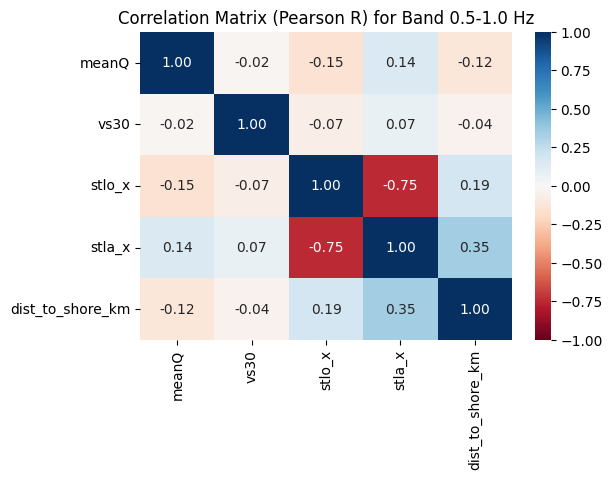

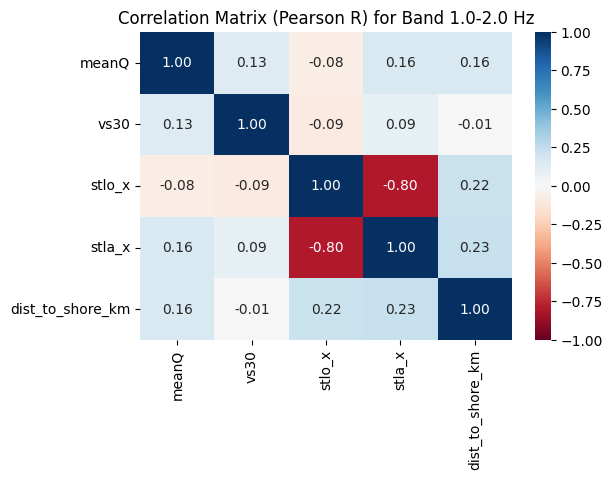

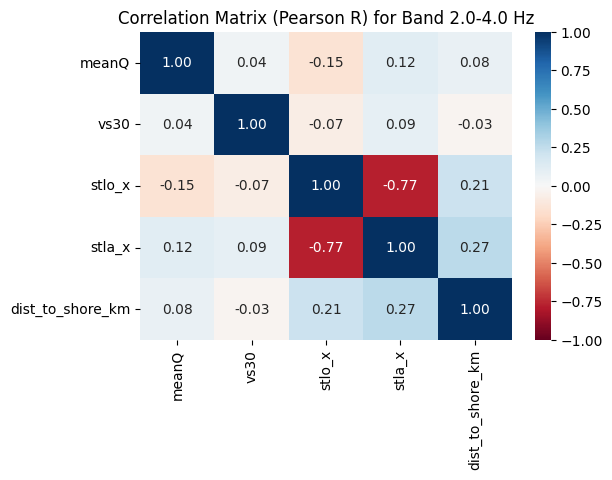

In [23]:
df=merged_geo.copy()

print("Calculating Correlation Matrices and Plotting Heatmaps:")
numerical_features = ['meanQ', 'vs30', 'stlo_x', 'stla_x', 'dist_to_shore_km']

for band in df['fband'].unique():
    band_data = df[df['fband'] == band][numerical_features].dropna()
    
    if band_data.shape[0] < 2:
        print(f"\nNot enough data for correlation plot in band {band}.")
        continue

    corr_matrix = band_data.corr(method='pearson')
    
    plt.figure(figsize=(6,4))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
    plt.title(f'Correlation Matrix (Pearson R) for Band {band} Hz')
    plt.show()




ANOVA Analysis and Box Plots for Mean Q across Lithology Types:

--- Band: 0.5-1.0 Hz ---
F-statistic: 1.22, P-value: 0.2562
Conclusion: There IS NO significant difference in mean Q values across general lithology types.


/tmp/ipykernel_3533631/3969660077.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='GENERALIZE', y='meanQ', data=band_data, height=6, aspect=3, palette='rainbow', order=order,
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 7.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Figure size 1200x600 with 0 Axes>

/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 9.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


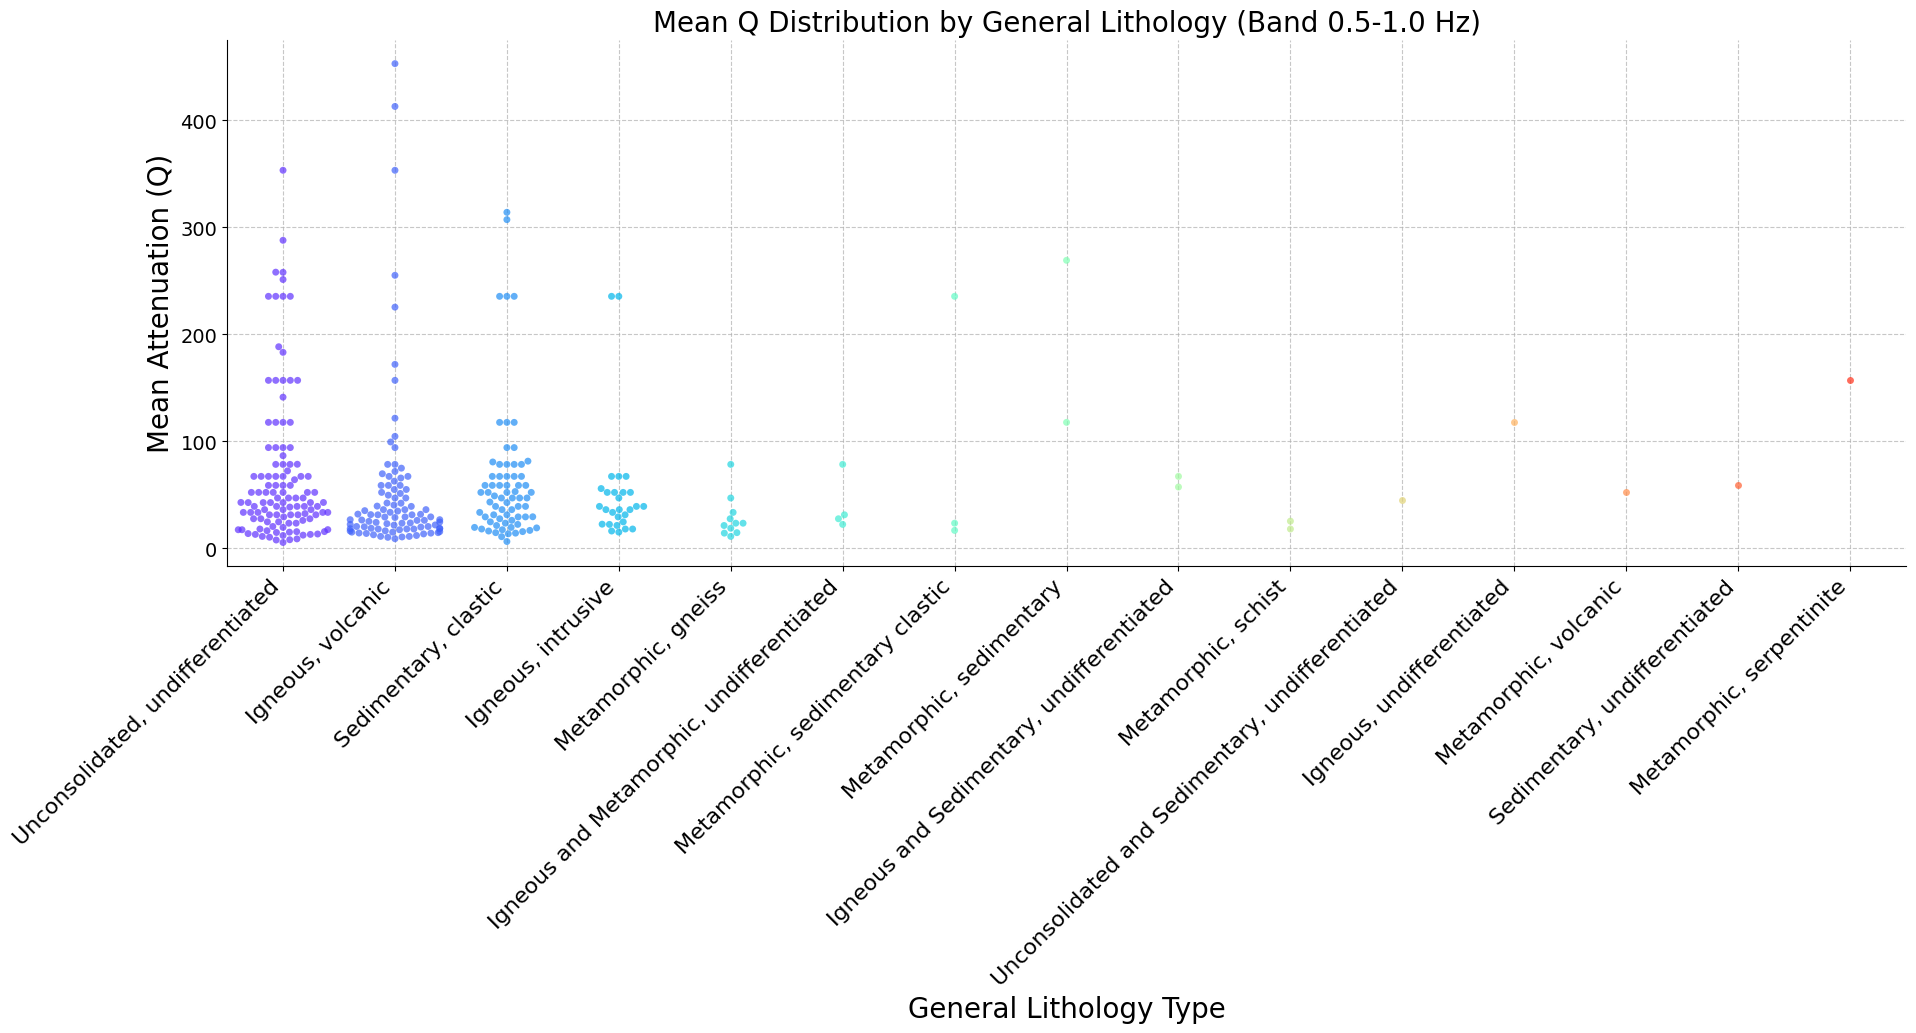


--- Band: 1.0-2.0 Hz ---
F-statistic: 2.70, P-value: 0.0012
Conclusion: There IS a significant difference in mean Q values across general lithology types.


/tmp/ipykernel_3533631/3969660077.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='GENERALIZE', y='meanQ', data=band_data, height=6, aspect=3, palette='rainbow', order=order,
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 16.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 5.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Figure size 1200x600 with 0 Axes>

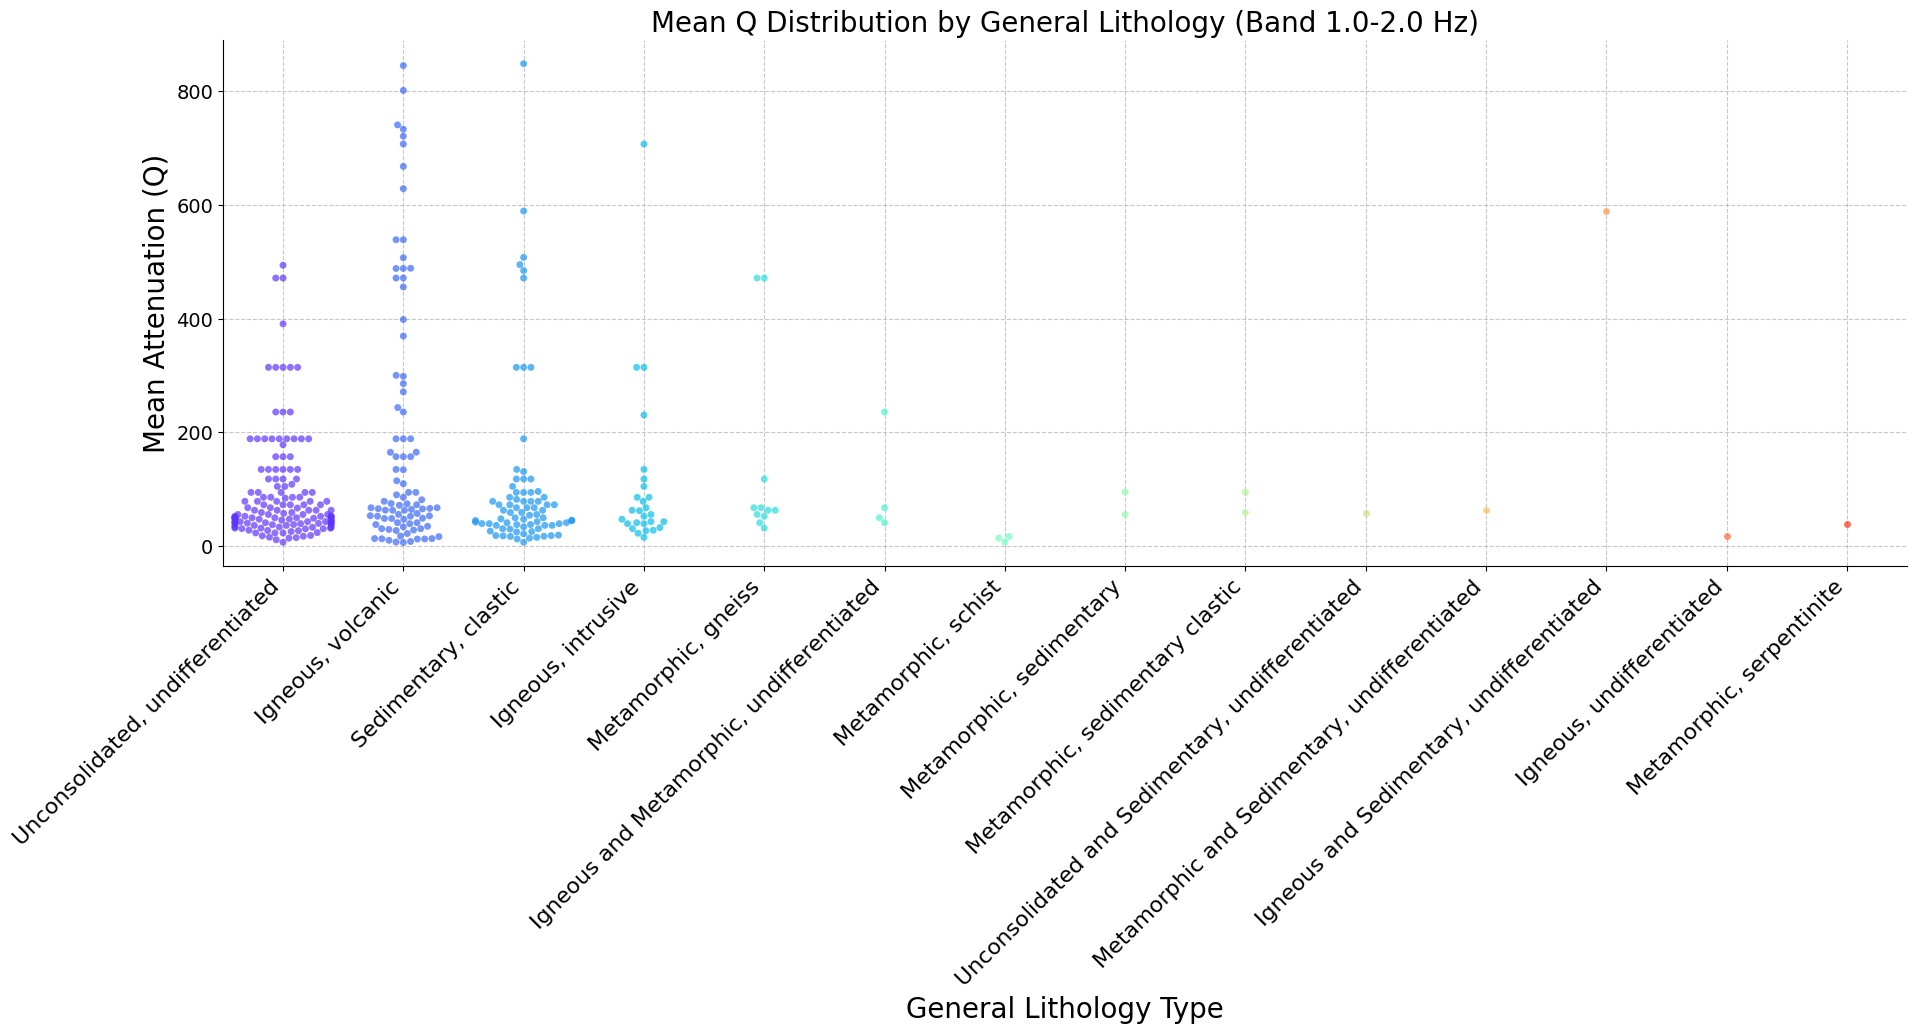


--- Band: 2.0-4.0 Hz ---
F-statistic: 1.09, P-value: 0.3683
Conclusion: There IS NO significant difference in mean Q values across general lithology types.


/tmp/ipykernel_3533631/3969660077.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='GENERALIZE', y='meanQ', data=band_data, height=6, aspect=3, palette='rainbow', order=order,
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 33.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 18.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.

<Figure size 1200x600 with 0 Axes>

/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 35.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 19.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


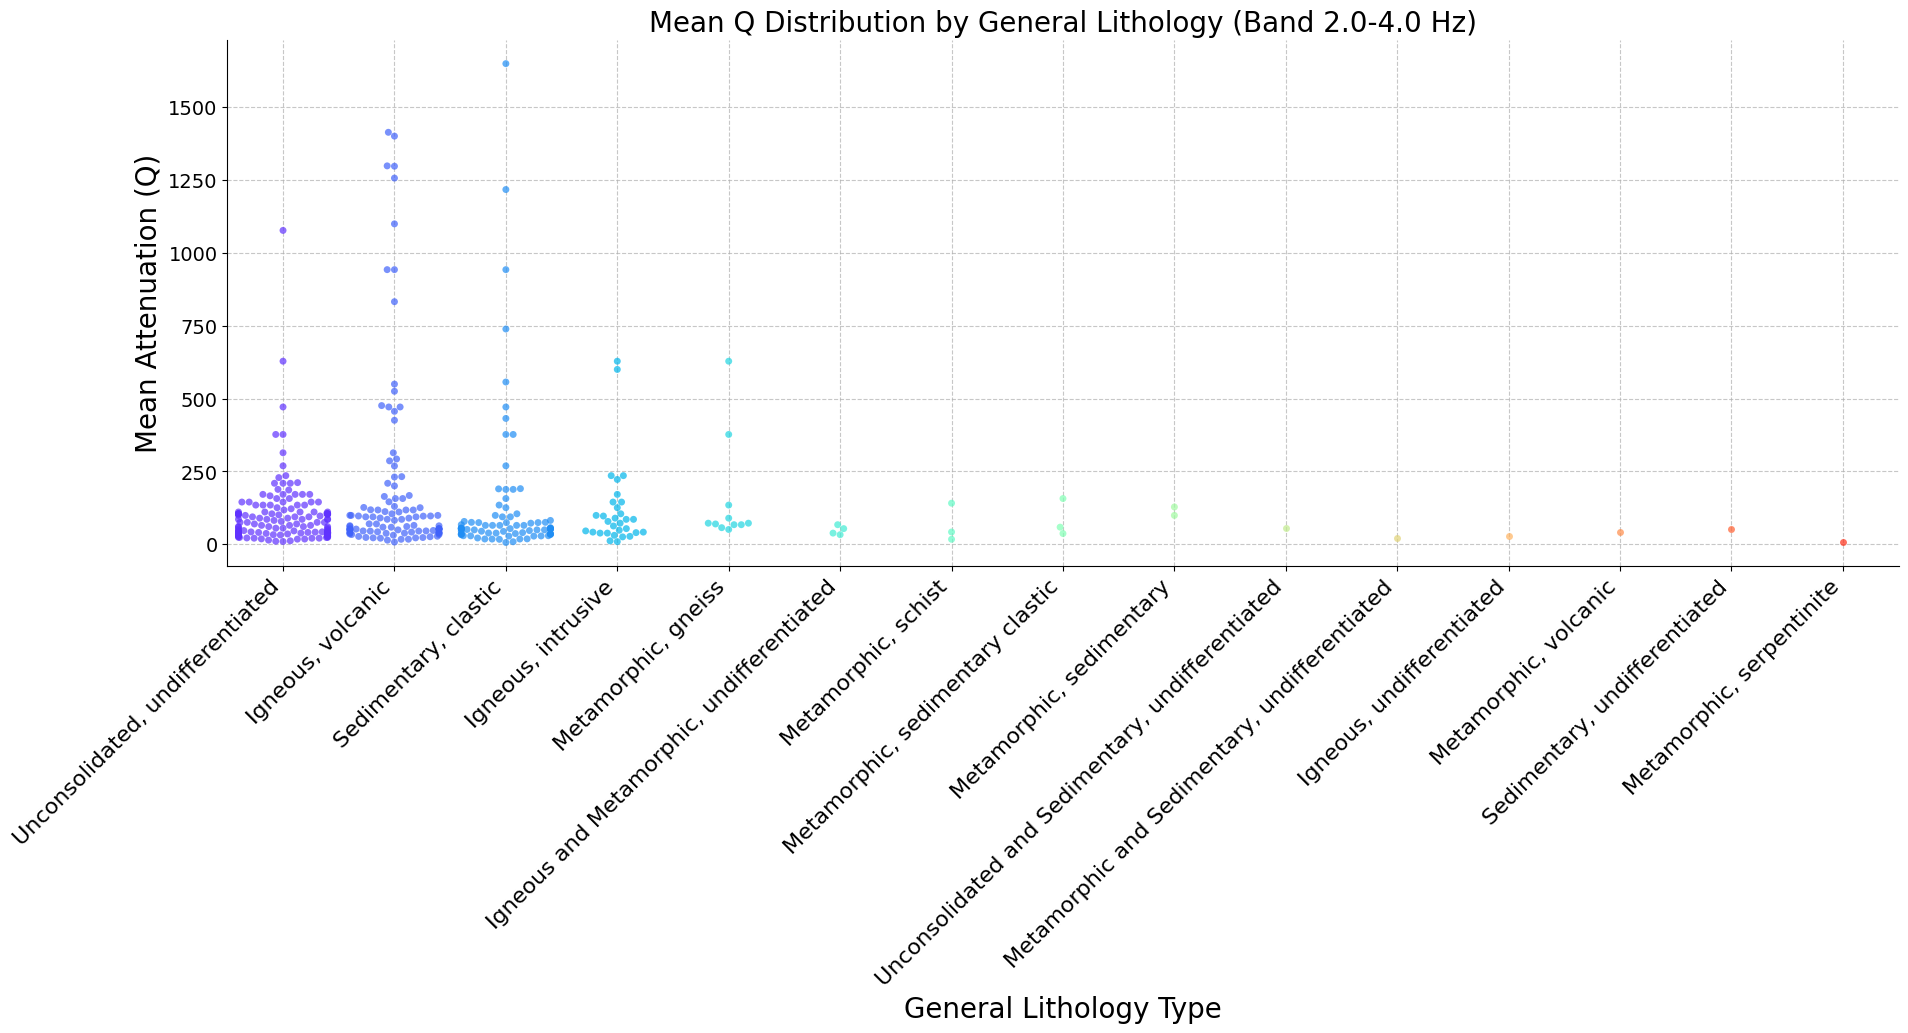

In [24]:
print("\nANOVA Analysis and Box Plots for Mean Q across Lithology Types:")

# Combine data for visualization across all bands if possible, or iterate band by band
for band in df['fband'].unique():
    band_data = df[df['fband'] == band].dropna(subset=['meanQ', 'GENERALIZE'])
    
    unique_lith = band_data['GENERALIZE'].unique()
    if len(unique_lith) >= 2:
        print(f"\n--- Band: {band} Hz ---")
        
        groups = [band_data['meanQ'][band_data['GENERALIZE'] == lt] for lt in unique_lith]
        f_statistic, p_value = stats.f_oneway(*groups)
        
        print(f"F-statistic: {f_statistic:.2f}, P-value: {p_value:.4f}")
        conclusion = "IS a significant difference" if p_value < 0.05 else "IS NO significant difference"
        print(f"Conclusion: There {conclusion} in mean Q values across general lithology types.")
        order = band_data['GENERALIZE'].value_counts().index
        
        # Plotting the results using a box plot
        plt.figure(figsize=(12, 6))
        sns.catplot(x='GENERALIZE', y='meanQ', data=band_data, height=6, aspect=3, palette='rainbow', order=order,
                    kind='swarm', alpha=0.7)
        plt.title(f'Mean Q Distribution by General Lithology (Band {band} Hz)', fontsize=20)
        plt.xlabel('General Lithology Type', fontsize=20)
        plt.ylabel('Mean Attenuation (Q)', fontsize=20)
        plt.xticks(rotation=45, ha='right', fontsize=16)
        plt.yticks(fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.7)

        plt.show()
    else:
        print(f"\nBand {band}: Not enough lithology variation for ANOVA analysis/plotting.")


In [25]:
from statsmodels.stats.multicomp import MultiComparison
import itertools
import string

def tukey_letters(tukey):
    """
    Assign letters for Tukey HSD significance.
    Groups sharing a letter are not significantly different.
    """
    groups = list(tukey.groupsunique)
    reject_df = pd.DataFrame(False, index=groups, columns=groups)

    # Fill rejection matrix
    for i in range(len(tukey.reject)):
        g1, g2 = tukey._results_table.data[i+1][0], tukey._results_table.data[i+1][1]
        reject = tukey.reject[i]
        reject_df.loc[g1, g2] = reject
        reject_df.loc[g2, g1] = reject

    letters = {g: '' for g in groups}
    current_letter = iter(string.ascii_lowercase)

    for g in groups:
        if letters[g]:  # already assigned
            continue
        letter = next(current_letter)
        letters[g] = letter
        for h in groups:
            if g == h:
                continue
            # Assign same letter if NOT rejected
            if not reject_df.loc[g, h]:
                letters[h] += letter
    return letters



ANOVA Analysis and Box Plots for Mean Q across Lithology Types:

--- Band: 0.5-1.0 Hz ---
Descriptive statistics for top lithologies:
                                  count       mean        std
GENERALIZE                                                   
Igneous, intrusive                   28  52.351964  54.093625
Igneous, volcanic                    93  54.963663  77.257986
Metamorphic, gneiss                  11  28.605818  19.392040
Sedimentary, clastic                 70  62.527842  63.279016
Unconsolidated, undifferentiated    113  69.502906  69.940859
ANOVA F-statistic: 1.35, P-value: 0.2519
Conclusion: There IS NO significant difference in mean Q values across general lithology types.


/tmp/ipykernel_3533631/3191045628.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GENERALIZE', y='meanQ', data=band_data_top, order=order, palette='rainbow')


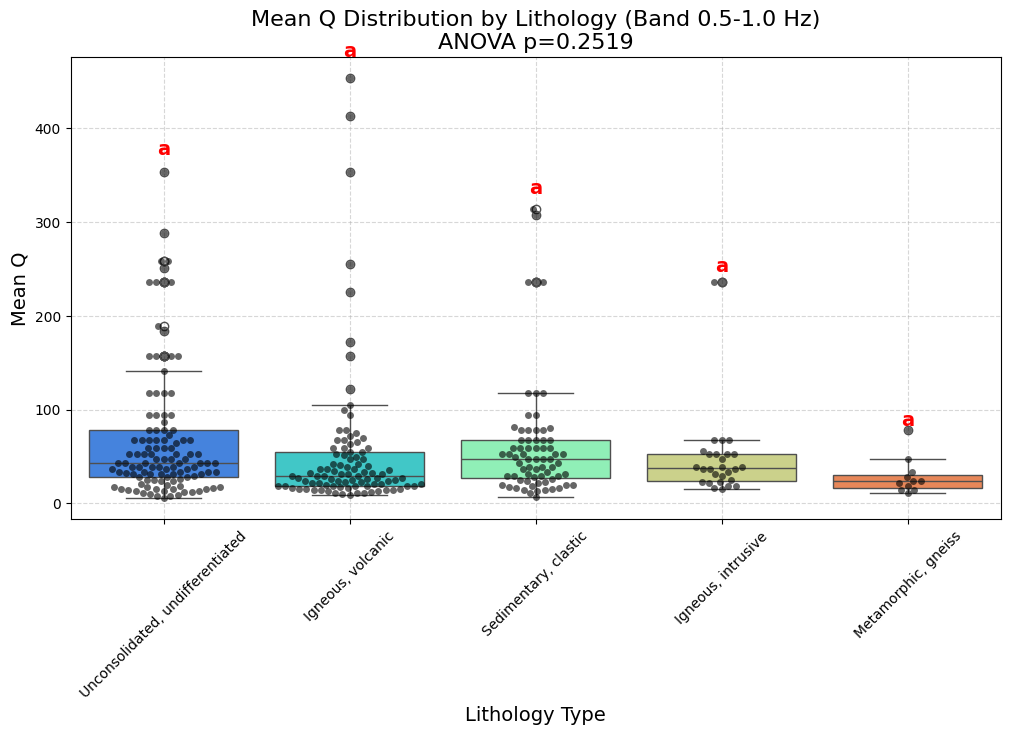


--- Band: 1.0-2.0 Hz ---
Descriptive statistics for top lithologies:
                                  count        mean         std
GENERALIZE                                                     
Igneous, intrusive                   27  106.669583  144.078632
Igneous, volcanic                    89  190.922784  224.807301
Metamorphic, gneiss                  11  136.435000  166.940981
Sedimentary, clastic                 77  106.701998  151.672552
Unconsolidated, undifferentiated    137   94.469919   93.494456
ANOVA F-statistic: 5.64, P-value: 0.0002
Conclusion: There IS a significant difference in mean Q values across general lithology types.

Tukey HSD post-hoc test results:
                      Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
       group1                     group2              meandiff p-adj    lower    upper   reject
-----------------------------------------------------------------------------------------------
  Igneous, intrusive    

/tmp/ipykernel_3533631/3191045628.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GENERALIZE', y='meanQ', data=band_data_top, order=order, palette='rainbow')
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


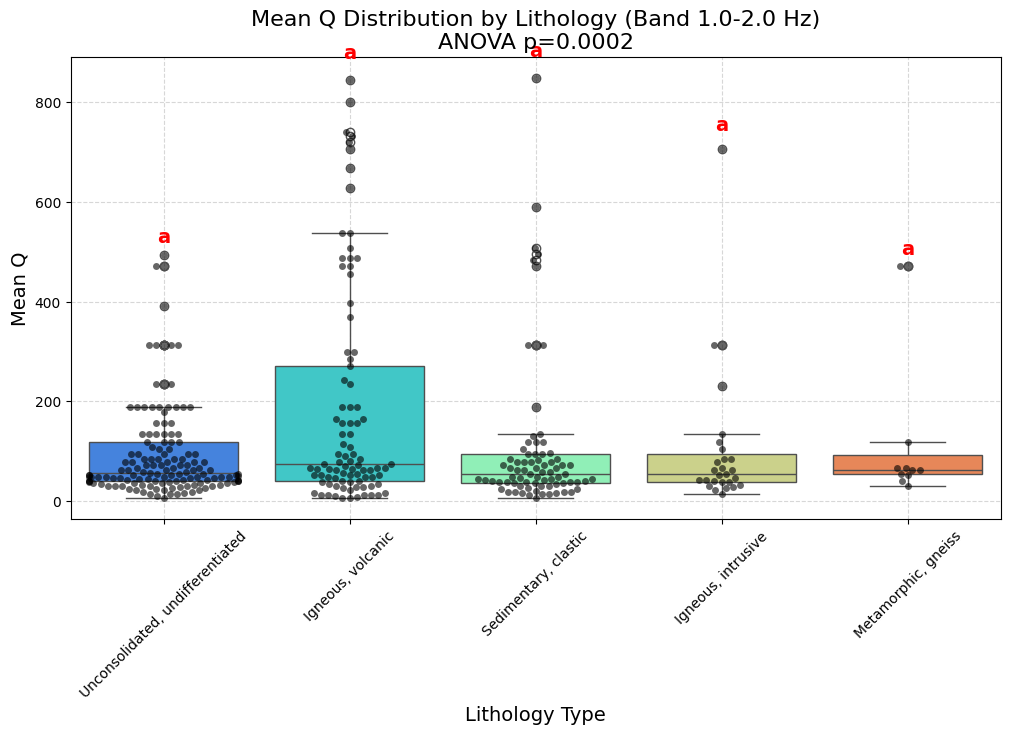


--- Band: 2.0-4.0 Hz ---
Descriptive statistics for top lithologies:
                                  count        mean         std
GENERALIZE                                                     
Igneous, intrusive                   31  120.608185  145.832131
Igneous, volcanic                   103  206.678736  326.071602
Metamorphic, gneiss                  11  153.384000  182.922505
Sedimentary, clastic                 80  141.586128  263.758858
Unconsolidated, undifferentiated    140  102.219443  120.899875
ANOVA F-statistic: 3.10, P-value: 0.0156
Conclusion: There IS a significant difference in mean Q values across general lithology types.

Tukey HSD post-hoc test results:
                      Multiple Comparison of Means - Tukey HSD, FWER=0.05                       
       group1                     group2               meandiff p-adj    lower    upper   reject
------------------------------------------------------------------------------------------------
  Igneous, intrusive 

/tmp/ipykernel_3533631/3191045628.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GENERALIZE', y='meanQ', data=band_data_top, order=order, palette='rainbow')
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 22.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 9.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/uufs/chpc.utah.edu/common/home/u6041347/software/pkg/miniconda3/envs/codetest/lib/python3.9/site-packages/s

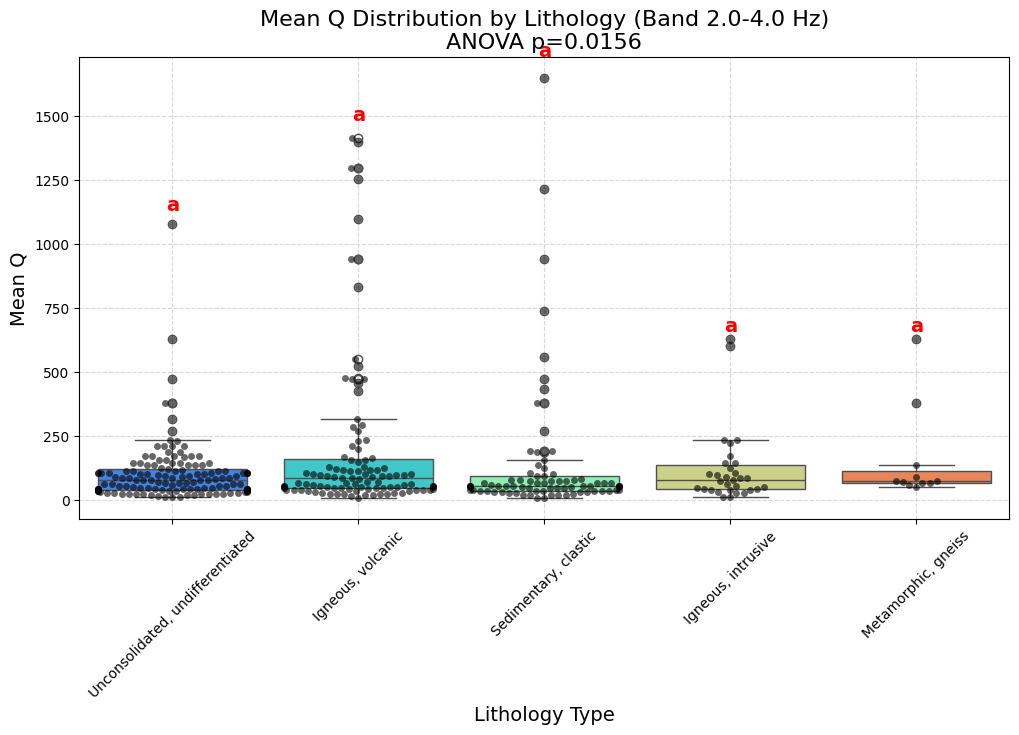

In [26]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

topN = 5  # top lithology types by count

print("\nANOVA Analysis and Box Plots for Mean Q across Lithology Types:")

for band in df['fband'].unique():
    band_data = df[df['fband'] == band].dropna(subset=['meanQ', 'GENERALIZE'])
    
    if band_data.empty:
        print(f"\nBand {band}: No data available.")
        continue

    # Select top N lithologies by count
    top_liths = band_data['GENERALIZE'].value_counts().index[:topN]
    band_data_top = band_data[band_data['GENERALIZE'].isin(top_liths)]

    mc = MultiComparison(band_data_top['meanQ'], band_data_top['GENERALIZE'])
    tukey_result = mc.tukeyhsd()
    group_letters = tukey_letters(tukey_result)
    
    # Descriptive statistics
    desc_stats = band_data_top.groupby('GENERALIZE')['meanQ'].agg(['count', 'mean', 'std'])
    print(f"\n--- Band: {band} Hz ---")
    print("Descriptive statistics for top lithologies:")
    print(desc_stats)
    
    # Ensure each group has at least 2 samples
    valid_liths = desc_stats[desc_stats['count'] >= 2].index
    if len(valid_liths) < 2:
        print(f"Band {band}: Not enough lithology variation with sufficient samples for ANOVA.")
        continue
    
    # ANOVA
    groups = [band_data_top['meanQ'][band_data_top['GENERALIZE'] == lt] for lt in valid_liths]
    f_statistic, p_value = stats.f_oneway(*groups)
    conclusion = "IS a significant difference" if p_value < 0.05 else "IS NO significant difference"
    print(f"ANOVA F-statistic: {f_statistic:.2f}, P-value: {p_value:.4f}")
    print(f"Conclusion: There {conclusion} in mean Q values across general lithology types.")
    
    # Tukey HSD post-hoc if significant
    if p_value < 0.05:
        tukey = pairwise_tukeyhsd(endog=band_data_top['meanQ'],
                                  groups=band_data_top['GENERALIZE'],
                                  alpha=0.05)
        print("\nTukey HSD post-hoc test results:")
        print(tukey.summary())
    
    # Plotting
    order = band_data_top['GENERALIZE'].value_counts().index
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='GENERALIZE', y='meanQ', data=band_data_top, order=order, palette='rainbow')
    sns.swarmplot(x='GENERALIZE', y='meanQ', data=band_data_top, order=order, color='k', alpha=0.6)
    plt.title(f'Mean Q Distribution by Lithology (Band {band} Hz)\nANOVA p={p_value:.4f}', fontsize=16)
    plt.xlabel('Lithology Type', fontsize=14)
    plt.ylabel('Mean Q', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    for i, lt in enumerate(order):
        y_max = band_data_top[band_data_top['GENERALIZE']==lt]['meanQ'].max()
        plt.text(i, y_max + 0.05*y_max, group_letters.get(lt,''), ha='center', fontsize=14, fontweight='bold', color='red')
    plt.show()



Random Forest Regression Analysis (Predicting MeanQ) and Feature Importance:

Analyzing Frequency Band: 0.5-1.0 Hz
Model R-squared score (on test data for 0.5-1.0 Hz): -0.048
Note: R-squared < 0 means the model performs worse than simply predicting the mean of the data.

Top Features for Predicting MeanQ in 0.5-1.0 Hz Band:
ncount              0.198739
dist_to_shore_km    0.194755
stla_x              0.169009
vs30                0.135555
stlo_x              0.122087
dtype: float64


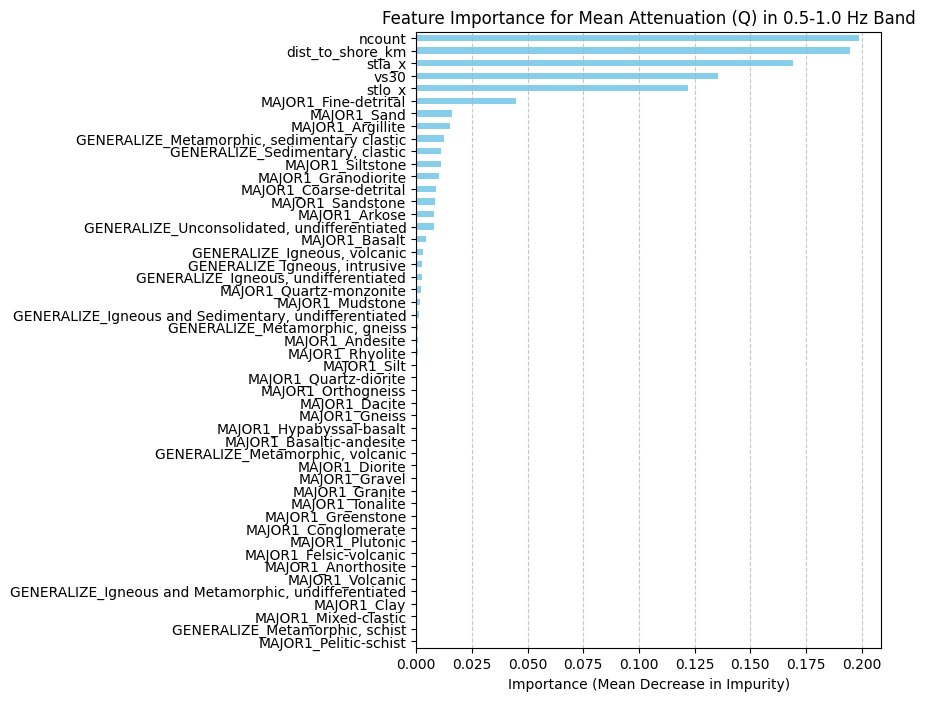


Analyzing Frequency Band: 1.0-2.0 Hz
Model R-squared score (on test data for 1.0-2.0 Hz): 0.048

Top Features for Predicting MeanQ in 1.0-2.0 Hz Band:
stlo_x              0.187033
stla_x              0.151315
vs30                0.149417
dist_to_shore_km    0.136235
ncount              0.097713
dtype: float64


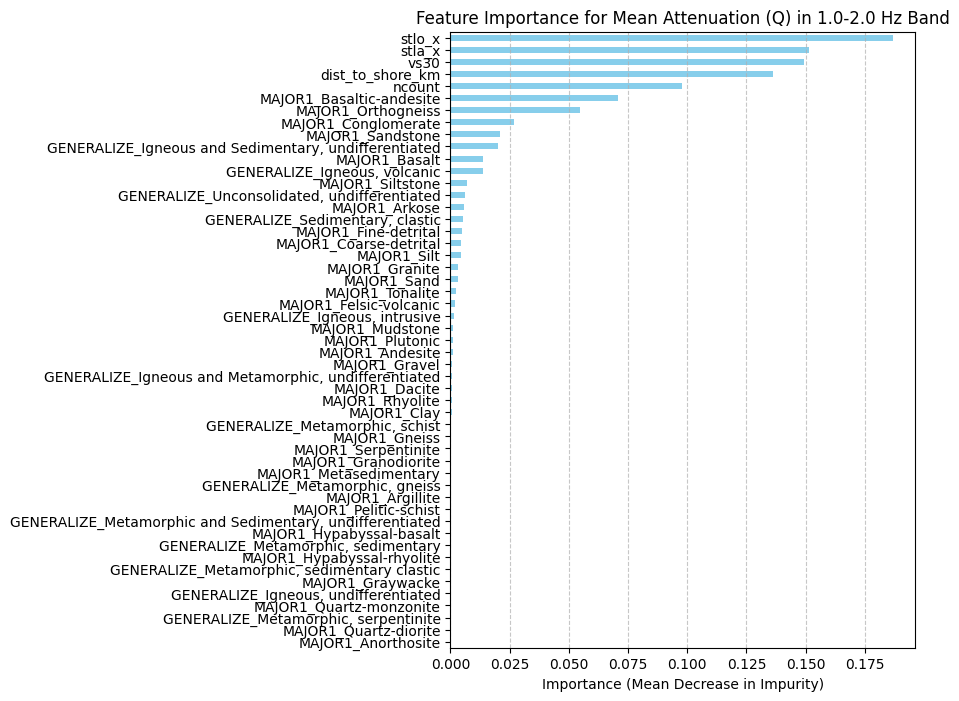


Analyzing Frequency Band: 2.0-4.0 Hz
Model R-squared score (on test data for 2.0-4.0 Hz): -0.836
Note: R-squared < 0 means the model performs worse than simply predicting the mean of the data.

Top Features for Predicting MeanQ in 2.0-4.0 Hz Band:
ncount              0.343739
stlo_x              0.184395
dist_to_shore_km    0.163185
vs30                0.110264
stla_x              0.094253
dtype: float64


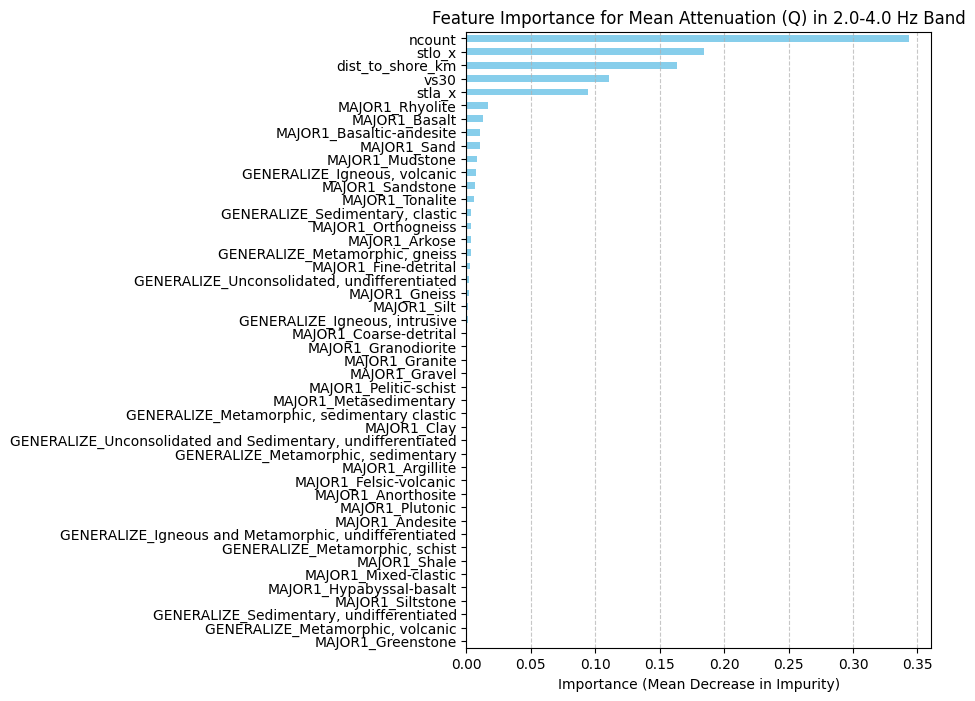

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


print("\nRandom Forest Regression Analysis (Predicting MeanQ) and Feature Importance:")
df=merged_geo.copy()
df=df.drop(["color_major", "color_gener", 'meanb',"nearest_lat", "nearest_lon"], axis=1, errors='ignore')

for band in df['fband'].unique():
    print(f"\n=====================================================")
    print(f"Analyzing Frequency Band: {band} Hz")
    print(f"=====================================================")

    # 1. Prepare data specific to this band
    df_band = df[df['fband'] == band].copy()
    
    # One-hot encode categorical features within this band's data
    df_band_encoded = pd.get_dummies(df_band, columns=['GENERALIZE', 'MAJOR1'], dummy_na=True)
    
    # Drop rows with missing values in core prediction features
    df_band_cleaned = df_band_encoded.dropna(subset=['meanQ', 'vs30', 'stlo_x', 'stla_x'])
    
    # Define features (X) and target (y)
    exclude_cols = ['meanQ', 'netst', 'geometry', 'STATE', 'fband']
    features_cols = [col for col in df_band_cleaned.columns if col not in exclude_cols]
    
    X = df_band_cleaned[features_cols]
    y = df_band_cleaned['meanQ']

    # Need sufficient data points for a meaningful train/test split and model training
    if len(X) < 10: 
        print(f"Skipping band {band}: Not enough data points ({len(X)}) for robust regression analysis.")
        continue

    # 2. Split data (e.g., 70% train, 30% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 3. Initialize and train the Random Forest Regressor
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    # 4. Evaluate the model
    predictions = rf.predict(X_test)
    r2 = r2_score(y_test, predictions)
    print(f"Model R-squared score (on test data for {band} Hz): {r2:.3f}")
    if r2 < 0:
        print("Note: R-squared < 0 means the model performs worse than simply predicting the mean of the data.")

    # 5. Extract and Plot Feature Importances
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    print(f"\nTop Features for Predicting MeanQ in {band} Hz Band:")
    print(importances.head(5))
    
    # Plotting Feature Importance
    plt.figure(figsize=(6, 8))
    # Filter to show only features with non-zero importance for clarity
    importances[importances > 0].sort_values().plot(kind='barh', color='skyblue')
    plt.title(f'Feature Importance for Mean Attenuation (Q) in {band} Hz Band')
    plt.xlabel('Importance (Mean Decrease in Impurity)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()


In [28]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Optional
try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception:
    HDBSCAN_AVAILABLE = False

# ---------------------------
# Helper functions
# ---------------------------
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def safe_train_test_split(X, y, test_size=0.2, random_state=42):
    try:
        return train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)
    except Exception as e:
        print("⚠️ Stratified split failed:", e)
        print("➡️ Falling back to non-stratified split.")
        return train_test_split(X, y, test_size=test_size, shuffle=True, random_state=random_state)

def plot_latlon(df_band, color_col, outpath, title="", palette=""):
    plt.figure(figsize=(4,6))
    sns.scatterplot(data=df_band, x='stlo_x', y='stla_x', hue=color_col, s=20, legend='brief', palette=palette)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    # plt.savefig(outpath, dpi=150); plt.close()

def plot_confusion_matrix(y_true, y_pred, labels, outpath, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    # plt.savefig(outpath, dpi=150); plt.close()

def plot_feature_importance(importances, feature_names, outpath, title="Feature importance"):
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(6,4))
    fi.plot(kind='bar')
    plt.title(title); plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(outpath, dpi=150); plt.close()

def plot_pred_vs_obs(y_true, y_pred, outpath, title="Predicted vs Observed"):
    plt.figure(figsize=(4,4))
    sns.scatterplot(x=y_true, y=y_pred)
    mn, mx = min(min(y_true), min(y_pred)), max(max(y_true), max(y_pred))
    plt.plot([mn,mx],[mn,mx], '--', color='k')
    plt.xlabel("Observed"); plt.ylabel("Predicted"); plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    # plt.savefig(outpath, dpi=150); plt.close()


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def interpret_kmeans_clusters(df, kmeans, scaler, FEATURES, TARGET,
                              figsize=(6,4), return_summary=True):
    """
    Full KMeans interpretation pipeline:
    - Unscaled centroids
    - Feature distribution per cluster
    - Lithology composition
    - Human-readable interpretation
    """

    # ---------------------------
    # 1. Unscaled centroids
    # ---------------------------
    centroids_unscaled = pd.DataFrame(
        scaler.inverse_transform(kmeans.cluster_centers_),
        columns=FEATURES
    )
    print("\n======================")
    print("Cluster Centroids (Unscaled)")
    print("======================")
    display(centroids_unscaled)

    # Attach cluster labels to dataframe
    df = df.copy()
    df["kmeans_cluster"] = kmeans.labels_

    # ---------------------------
    # 2. Feature distributions
    # ---------------------------
    print("\n======================")
    print("Feature Distributions per Cluster")
    print("======================")

    for feat in FEATURES:
        plt.figure(figsize=figsize)
        sns.boxplot(data=df, x="kmeans_cluster", y=feat, palette="viridis")
        plt.title(f"{feat} distribution per cluster")
        plt.show()

    # ---------------------------
    # 3. Lithology composition
    # ---------------------------
    print("\n======================")
    print("Lithology Composition Within Each Cluster")
    print("======================")

    lithology = (
        df.groupby("kmeans_cluster")[TARGET]
        .value_counts(normalize=True)
        .rename("fraction")
        .reset_index()
    )
    display(lithology)

    # ---------------------------
    # 4. Textual interpretation
    # ---------------------------
    print("\n======================")
    print("Cluster Interpretation")
    print("======================")

    interpretations = []

    for i in centroids_unscaled.index:
        c = centroids_unscaled.loc[i]

        desc = f"Cluster {i}: "

        # Interpret Vs30
        if c.vs30 < 300:
            desc += "Low Vs30 (soft sediments), "
        elif c.vs30 < 550:
            desc += "Medium Vs30 (sedimentary/clastic), "
        else:
            desc += "High Vs30 (volcanic/crystalline), "

        # Interpret meanQ
        if c.meanQ < 50:
            desc += "Low Q, "
        elif c.meanQ < 150:
            desc += "Moderate Q, "
        else:
            desc += "High Q, "

        # Interpret shoreline distance
        if c.dist_to_shore_km < 20:
            desc += "very near shore"
        elif c.dist_to_shore_km < 120:
            desc += "moderate distance from shore"
        else:
            desc += "far inland"

        print(desc)
        interpretations.append(desc)

    # Return summary for further processing
    if return_summary:
        summary = {
            "centroids_unscaled": centroids_unscaled,
            "lithology_fractions": lithology,
            "interpretations": interpretations,
            "df_with_clusters": df,
        }
        return summary



Fband: 0.5-1.0
k=2, silhouette=0.328
k=3, silhouette=0.351
k=4, silhouette=0.408
k=5, silhouette=0.326
k=6, silhouette=0.332

Best K = 4


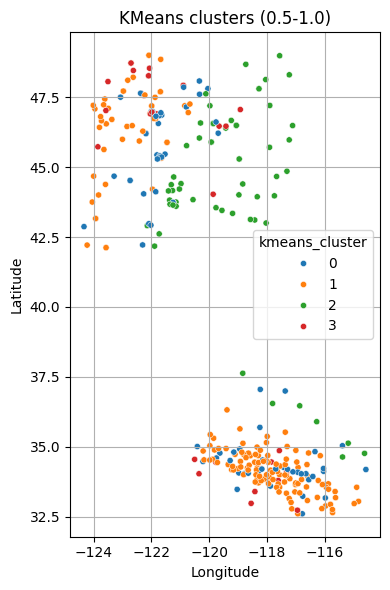

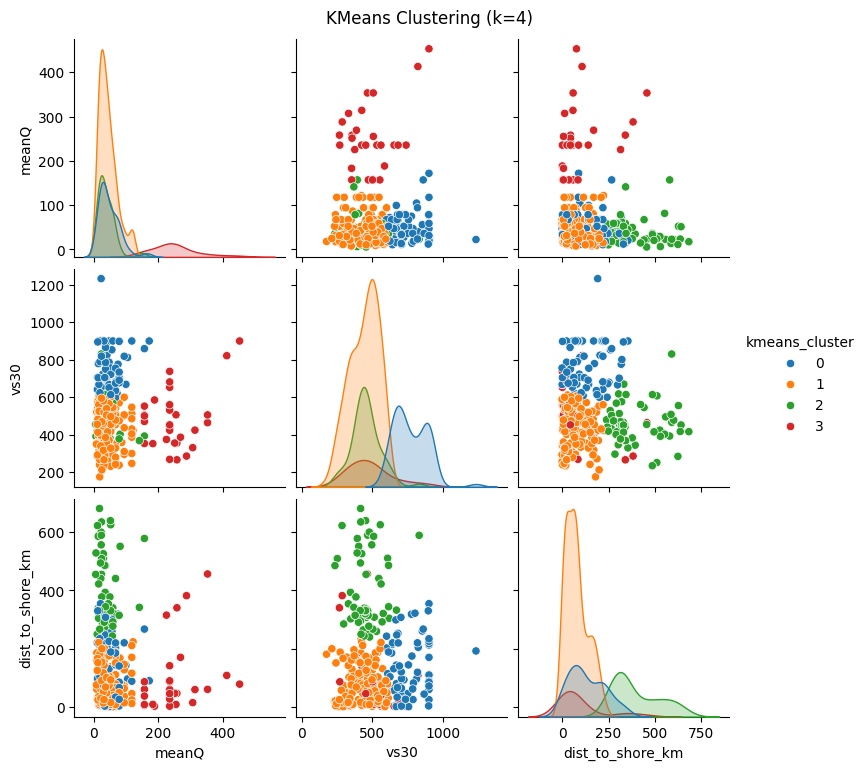


Cluster Centroids (Unscaled)


,meanQ,vs30,dist_to_shore_km
0,47.711429,769.575310,134.661958
1,42.918324,440.854422,76.681183
2,38.034195,453.577805,398.046759
3,250.450684,482.509393,92.623680



Feature Distributions per Cluster


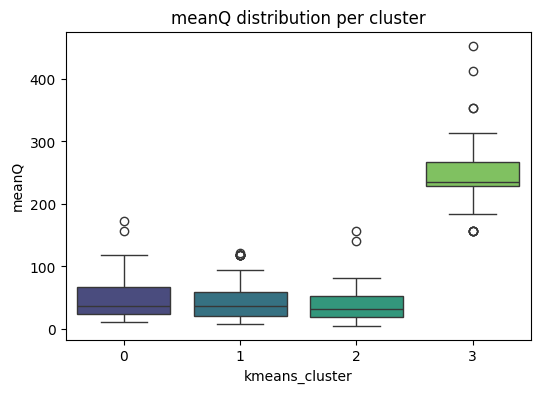

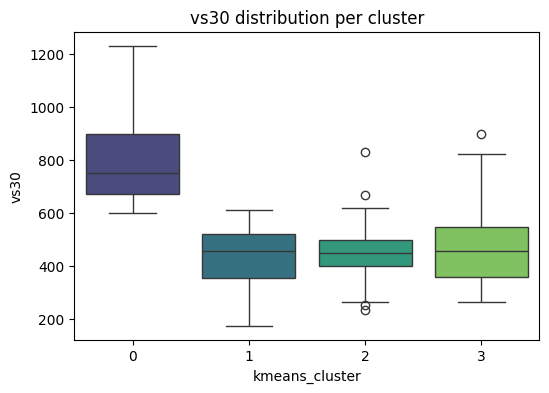

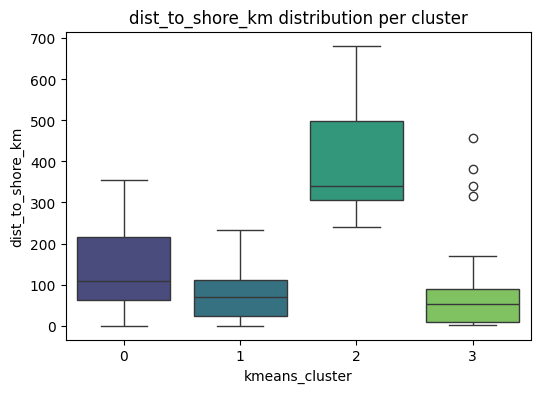


Lithology Composition Within Each Cluster


,kmeans_cluster,GENERALIZE,fraction
0,0,"Igneous, volcanic",0.436620
1,0,"Sedimentary, clastic",0.169014
2,0,"Igneous, intrusive",0.112676
3,0,"Metamorphic, gneiss",0.112676
4,0,"Unconsolidated, undifferentiated",0.098592
5,0,"Igneous and Metamorphic, undifferentiated",0.028169
6,0,"Igneous and Sedimentary, undifferentiated",0.014085
7,0,"Igneous, undifferentiated",0.014085
8,0,"Metamorphic, schist",0.014085
9,1,"Unconsolidated, undifferentiated",0.464286



Cluster Interpretation
Cluster 0: High Vs30 (volcanic/crystalline), Low Q, far inland
Cluster 1: Medium Vs30 (sedimentary/clastic), Low Q, moderate distance from shore
Cluster 2: Medium Vs30 (sedimentary/clastic), Low Q, far inland
Cluster 3: Medium Vs30 (sedimentary/clastic), High Q, moderate distance from shore

Fband: 1.0-2.0
k=2, silhouette=0.417
k=3, silhouette=0.385
k=4, silhouette=0.387
k=5, silhouette=0.389
k=6, silhouette=0.357

Best K = 2


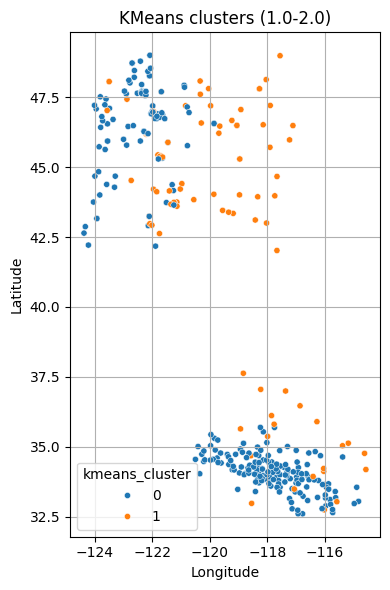

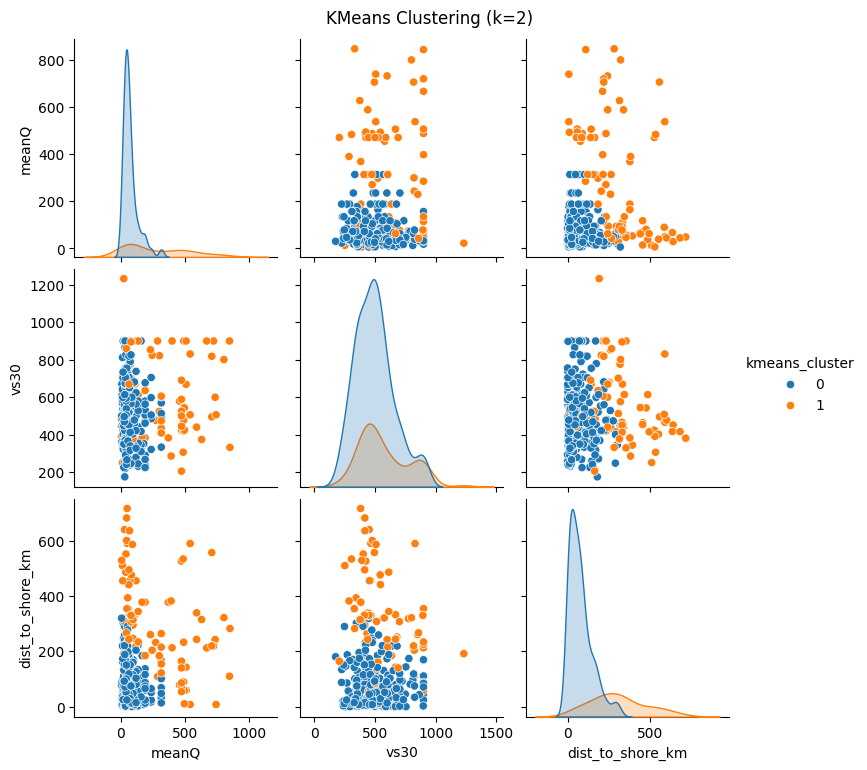


Cluster Centroids (Unscaled)


,meanQ,vs30,dist_to_shore_km
0,71.109891,496.212267,76.903491
1,278.293171,573.278809,305.552919



Feature Distributions per Cluster


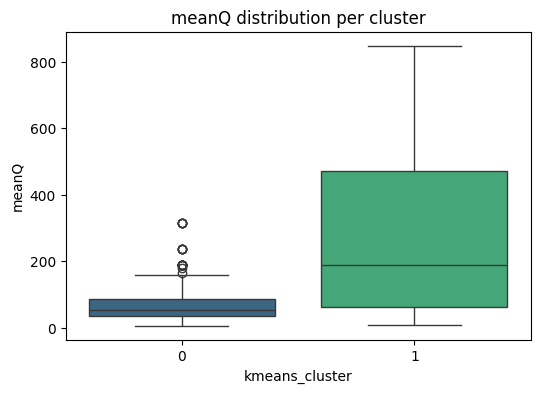

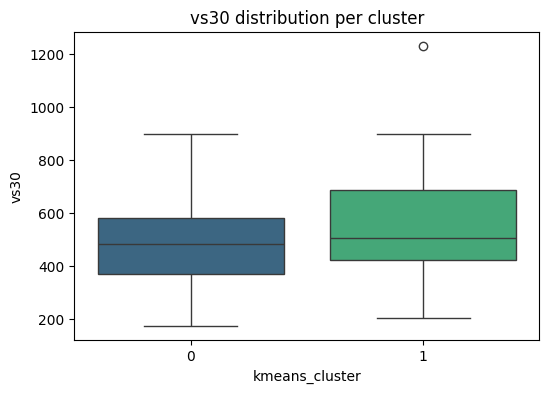

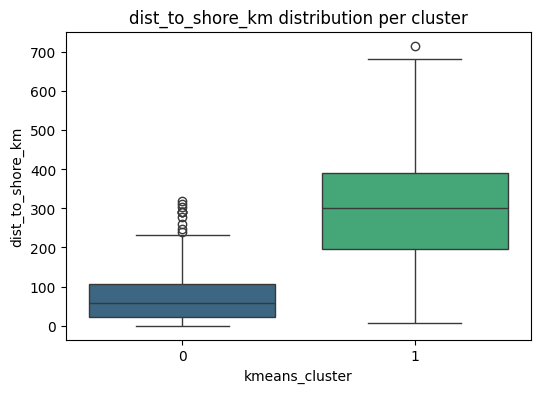


Lithology Composition Within Each Cluster


,kmeans_cluster,GENERALIZE,fraction
0,0,"Unconsolidated, undifferentiated",0.438202
1,0,"Sedimentary, clastic",0.235955
2,0,"Igneous, volcanic",0.164794
3,0,"Igneous, intrusive",0.074906
4,0,"Metamorphic, gneiss",0.033708
5,0,"Igneous and Metamorphic, undifferentiated",0.014981
6,0,"Metamorphic, schist",0.011236
7,0,"Metamorphic, sedimentary",0.007491
8,0,"Metamorphic, sedimentary clastic",0.007491
9,0,"Igneous, undifferentiated",0.003745



Cluster Interpretation
Cluster 0: Medium Vs30 (sedimentary/clastic), Moderate Q, moderate distance from shore
Cluster 1: High Vs30 (volcanic/crystalline), High Q, far inland

Fband: 2.0-4.0
k=2, silhouette=0.276
k=3, silhouette=0.399
k=4, silhouette=0.436
k=5, silhouette=0.435
k=6, silhouette=0.355

Best K = 4


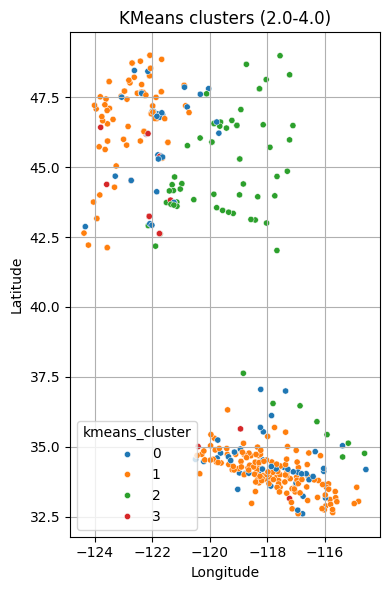

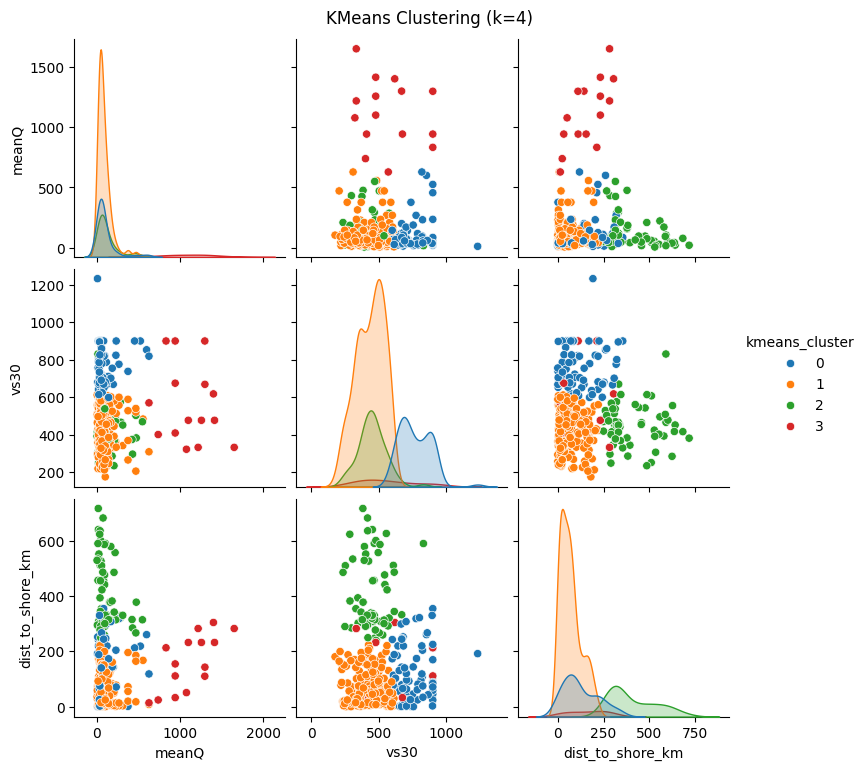


Cluster Centroids (Unscaled)


,meanQ,vs30,dist_to_shore_km
0,99.093711,766.826132,124.129824
1,93.170990,433.985687,68.444728
2,121.808372,449.063371,406.057025
3,1115.822569,564.049693,161.333643



Feature Distributions per Cluster


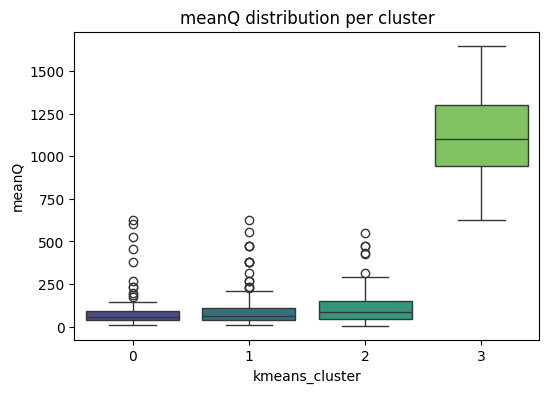

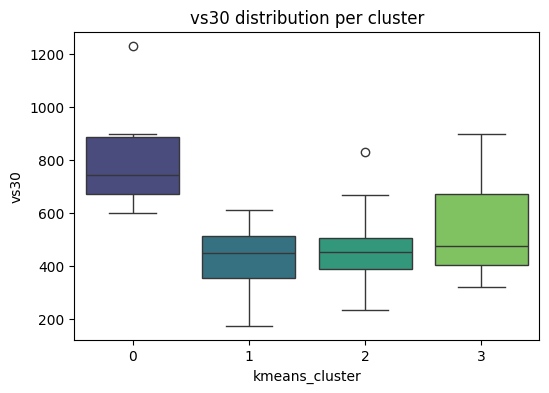

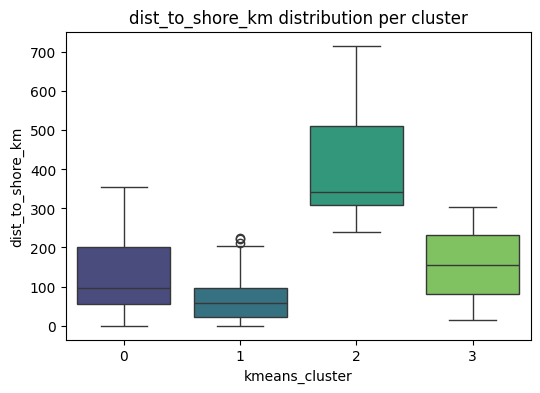


Lithology Composition Within Each Cluster


,kmeans_cluster,GENERALIZE,fraction
0,0,"Igneous, volcanic",0.384615
1,0,"Sedimentary, clastic",0.205128
2,0,"Igneous, intrusive",0.141026
3,0,"Metamorphic, gneiss",0.102564
4,0,"Unconsolidated, undifferentiated",0.089744
5,0,"Igneous and Metamorphic, undifferentiated",0.025641
6,0,"Igneous, undifferentiated",0.012821
7,0,"Metamorphic and Sedimentary, undifferentiated",0.012821
8,0,"Metamorphic, schist",0.012821
9,0,"Metamorphic, sedimentary clastic",0.012821



Cluster Interpretation
Cluster 0: High Vs30 (volcanic/crystalline), Moderate Q, far inland
Cluster 1: Medium Vs30 (sedimentary/clastic), Moderate Q, moderate distance from shore
Cluster 2: Medium Vs30 (sedimentary/clastic), Moderate Q, far inland
Cluster 3: High Vs30 (volcanic/crystalline), High Q, far inland


In [43]:

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

df = merged_geo.copy()
df=df.drop(["color_major", "color_gener", 'meanb',"nearest_lat", "nearest_lon"], axis=1, errors='ignore')

# Create results root
ROOT = "results_kmeans"
ensure_dir(ROOT)
for fband in df['fband'].unique():
    print("\n" + "="*70)
    print("Fband:", fband)
    print("="*70)
    outdir = os.path.join(ROOT, fband.replace("/", "-"))
    ensure_dir(outdir)

    df_band = df[df['fband'] == fband].copy().reset_index(drop=True)
    
    FEATURES = ['meanQ', 'vs30', 'dist_to_shore_km']
    TARGET   = 'GENERALIZE'

    df_band = df_band.dropna(subset=FEATURES + [TARGET])  # clean

    X = df_band[FEATURES].values
    y = df_band[TARGET].values

    # scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # encode labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    
    sil_scores = {}
    models = {}

    for k in range(2, 7):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        sil_scores[k] = score
        models[k] = kmeans
        print(f"k={k}, silhouette={score:.3f}")

    best_k = max(sil_scores, key=sil_scores.get)
    best_kmeans = models[best_k]
    df_band['kmeans_cluster'] = best_kmeans.labels_

    print("\nBest K =", best_k)
    # cluster_lith = df_band.groupby('kmeans_cluster')['GENERALIZE'].value_counts(normalize=True)
    # print(cluster_lith)    

    plot_latlon(df_band, 'kmeans_cluster', os.path.join(outdir, 'kmeans_latlon.png'), 
                title=f"KMeans clusters ({fband})", palette='tab10')

    sns.pairplot(df_band, vars=FEATURES, hue='kmeans_cluster', palette='tab10')
    plt.suptitle(f"KMeans Clustering (k={best_k})", y=1.02)
    plt.show()

    # FIXED: Use `best_kmeans` instead of `kmeans`
    interpret_kmeans_clusters(
        df=df_band,
        kmeans=best_kmeans,     # ← Correct model
        scaler=scaler,
        FEATURES=FEATURES,
        TARGET=TARGET
    )

    





Fband: 0.5-1.0


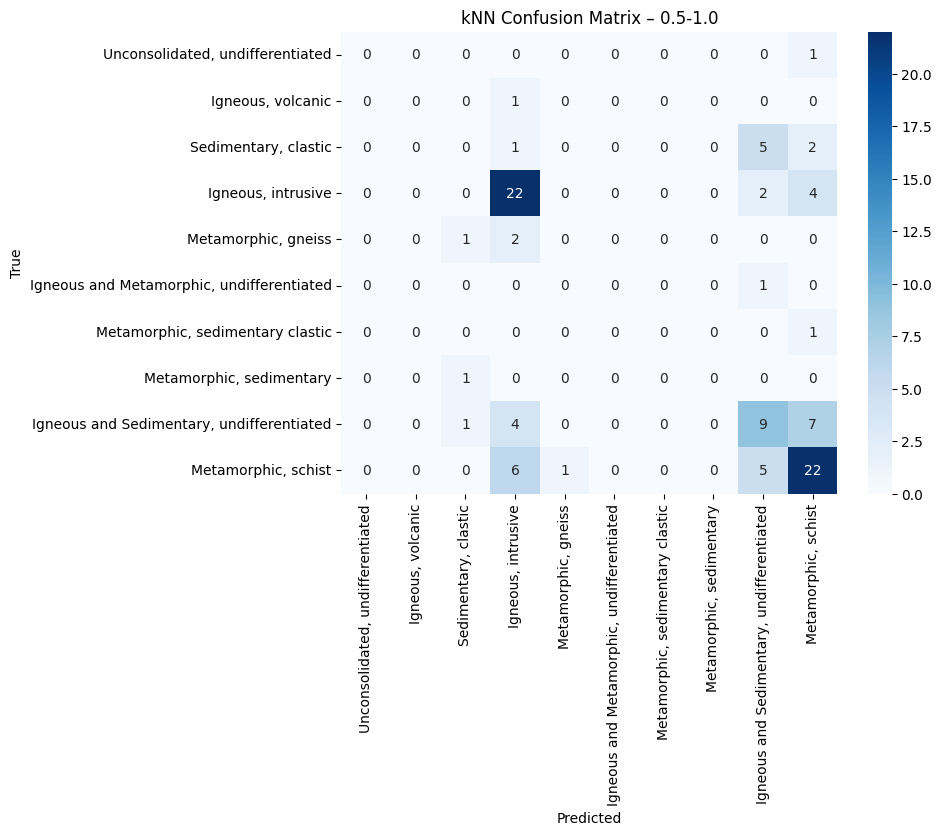


Classification Report:
                                           precision    recall  f1-score   support

         Unconsolidated, undifferentiated       0.00      0.00      0.00         1
                        Igneous, volcanic       0.00      0.00      0.00         1
                     Sedimentary, clastic       0.00      0.00      0.00         8
                       Igneous, intrusive       0.61      0.79      0.69        28
                      Metamorphic, gneiss       0.00      0.00      0.00         3
Igneous and Metamorphic, undifferentiated       0.00      0.00      0.00         1
         Metamorphic, sedimentary clastic       0.00      0.00      0.00         1
                 Metamorphic, sedimentary       0.00      0.00      0.00         1
Igneous and Sedimentary, undifferentiated       0.41      0.43      0.42        21
                      Metamorphic, schist       0.59      0.65      0.62        34

                                 accuracy                    

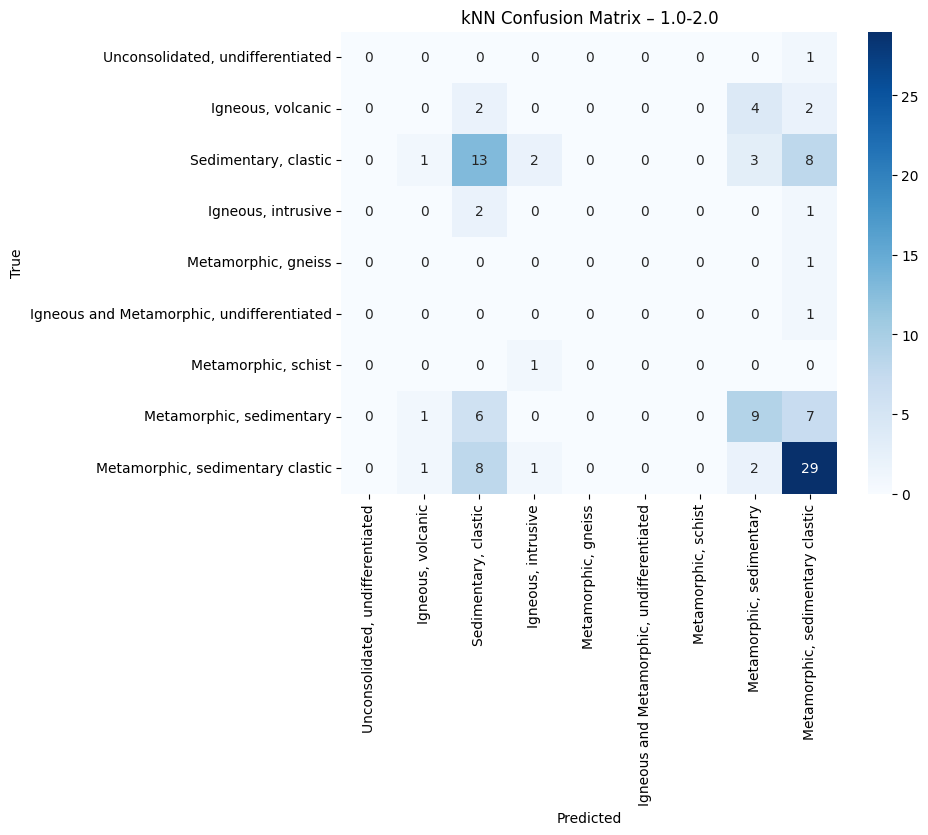


Classification Report:
                                           precision    recall  f1-score   support

         Unconsolidated, undifferentiated       0.00      0.00      0.00         1
                        Igneous, volcanic       0.00      0.00      0.00         8
                     Sedimentary, clastic       0.42      0.48      0.45        27
                       Igneous, intrusive       0.00      0.00      0.00         3
                      Metamorphic, gneiss       0.00      0.00      0.00         1
Igneous and Metamorphic, undifferentiated       0.00      0.00      0.00         1
                      Metamorphic, schist       0.00      0.00      0.00         1
                 Metamorphic, sedimentary       0.50      0.39      0.44        23
         Metamorphic, sedimentary clastic       0.58      0.71      0.64        41

                                 accuracy                           0.48       106
                                macro avg       0.17      0.1

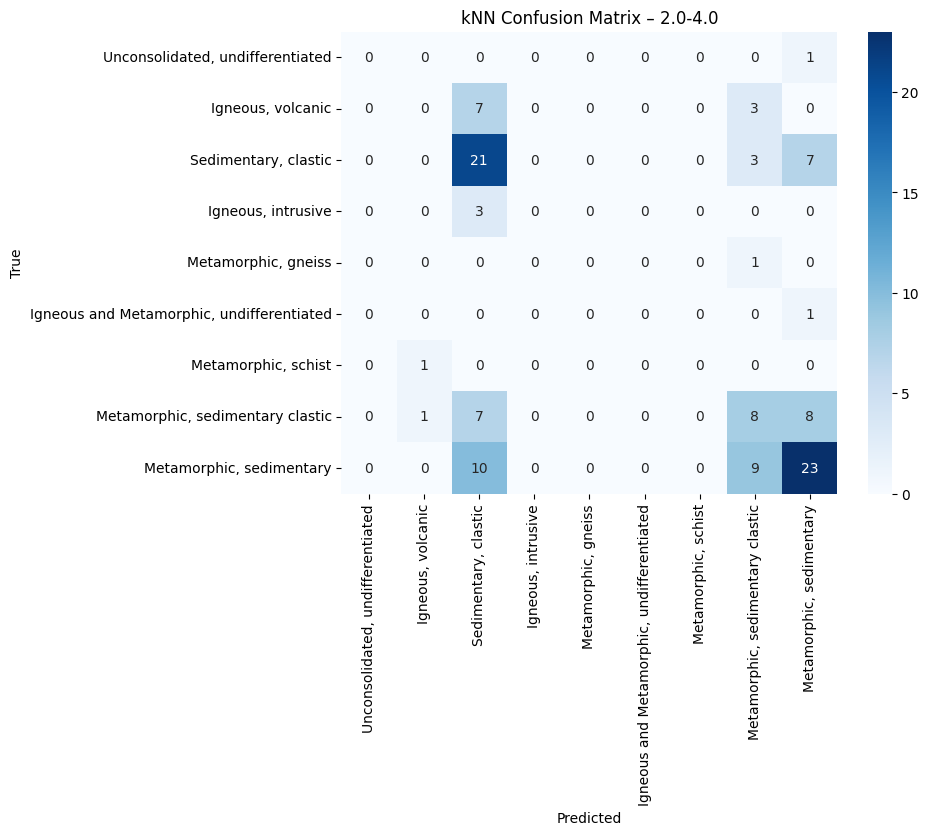


Classification Report:
                                           precision    recall  f1-score   support

         Unconsolidated, undifferentiated       0.00      0.00      0.00         1
                        Igneous, volcanic       0.00      0.00      0.00        10
                     Sedimentary, clastic       0.44      0.68      0.53        31
                       Igneous, intrusive       0.00      0.00      0.00         3
                      Metamorphic, gneiss       0.00      0.00      0.00         1
Igneous and Metamorphic, undifferentiated       0.00      0.00      0.00         1
                      Metamorphic, schist       0.00      0.00      0.00         1
         Metamorphic, sedimentary clastic       0.33      0.33      0.33        24
                 Metamorphic, sedimentary       0.57      0.55      0.56        42

                                 accuracy                           0.46       114
                                macro avg       0.15      0.1

In [30]:
df = merged_geo.copy()

for fband in df['fband'].unique():
    print("\n" + "="*70)
    print("Fband:", fband)
    print("="*70)

    df_band = df[df['fband'] == fband].copy().reset_index(drop=True)

    FEATURES = ['meanQ', 'vs30', 'dist_to_shore_km']
    TARGET   = 'GENERALIZE'

    # remove missing values
    df2 = df_band.dropna(subset=FEATURES + [TARGET]).copy()

    # ------------------------------
    # 1) Encode labels PER FBAND
    # ------------------------------
    le = LabelEncoder()
    df2['label'] = le.fit_transform(df2[TARGET])
    y_enc = df2['label'].values

    # ------------------------------
    # 2) Drop classes with <2 samples (kNN requirement)
    # ------------------------------
    counts = df2['label'].value_counts()
    valid_classes = counts[counts >= 2].index.tolist()

    df2 = df2[df2['label'].isin(valid_classes)].reset_index(drop=True)
    y_enc = df2['label'].values

    if len(valid_classes) < 2:
        print("⚠ Not enough valid classes for kNN (need at least 2). Skipping.")
        continue

    # ------------------------------
    # 3) Scale features
    # ------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df2[FEATURES].values)

    # ------------------------------
    # 4) Stratified split (now valid)
    # ------------------------------
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y_enc,
        test_size=0.3,
        stratify=y_enc,
        random_state=42
    )

    # ------------------------------
    # 5) kNN classifier
    # ------------------------------
    knn = KNeighborsClassifier(n_neighbors=7)
    knn.fit(X_tr, y_tr)
    y_pred = knn.predict(X_te)

    # ------------------------------
    # 6) Plot confusion matrix
    # ------------------------------
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, cmap="Blues",
        xticklabels=le.inverse_transform(valid_classes),
        yticklabels=le.inverse_transform(valid_classes)
    )
    plt.title(f"kNN Confusion Matrix – {fband}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ------------------------------
    # 7) Print classification report
    # ------------------------------
    print("\nClassification Report:")
    print(
        classification_report(
            y_te, y_pred,
            target_names=le.inverse_transform(valid_classes),
            zero_division=0
        )
    )